RiceBorer-CLS: Calibrated YOLO26 classification and web-based screening of dead-heart and white-head symptoms in rice

Partha Pratim Ray, Sikkim University,India, 31 July, 2026

Dataset: https://data.mendeley.com/datasets/hnfjs42d5g/1

In [1]:
# Cell 1: Runtime and GPU inspection

import os
import sys
import platform
import subprocess

print("Python version :", sys.version)
print("Platform       :", platform.platform())

try:
    gpu_info = subprocess.check_output(
        ["nvidia-smi"],
        stderr=subprocess.STDOUT,
        text=True
    )
    print(gpu_info)
except Exception:
    print(
        "GPU was not detected. In Google Colab, select:\n"
        "Runtime > Change runtime type > T4 GPU"
    )

Python version : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35
Fri Jul 31 10:17:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                 

In [2]:
# Cell 2: Install research and deployment dependencies

!pip install -q -U ultralytics
!pip install -q scikit-learn pandas numpy matplotlib pillow seaborn
!pip install -q imagehash gradio openpyxl pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.8 MB/s eta 0:00:00


In [3]:
# Cell 3: Imports and reproducibility settings

import os
import gc
import re
import json
import time
import math
import random
import shutil
import hashlib
import zipfile
import warnings
import platform
import subprocess

from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile, UnidentifiedImageError
import imagehash

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    auc,
    log_loss,
    brier_score_loss
)
from sklearn.preprocessing import label_binarize

from ultralytics import YOLO
import ultralytics

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = False

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Deterministic settings improve reproducibility.
# Some GPU operations may still have minor numerical variation.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Ultralytics version:", ultralytics.__version__)
print("PyTorch version    :", torch.__version__)
print("CUDA available     :", torch.cuda.is_available())
print("Device             :", DEVICE)

if torch.cuda.is_available():
    print("GPU                :", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.113
PyTorch version    : 2.11.0+cu128
CUDA available     : True
Device             : 0
GPU                : Tesla T4


In [4]:
# Cell 4: Project directories and direct Mendeley file URL

from pathlib import Path

PROJECT_ROOT = Path("/content/rice_stem_borer_research")
DOWNLOAD_DIR = PROJECT_ROOT / "download"
EXTRACT_DIR = PROJECT_ROOT / "extracted"
PREPARED_DIR = PROJECT_ROOT / "prepared_dataset"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures_600dpi"
TABLE_DIR = RESULTS_DIR / "tables"
MODEL_DIR = RESULTS_DIR / "trained_models"
EXPORT_DIR = RESULTS_DIR / "exports"

for directory in [
    PROJECT_ROOT,
    DOWNLOAD_DIR,
    EXTRACT_DIR,
    PREPARED_DIR,
    RESULTS_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    MODEL_DIR,
    EXPORT_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

# Confirmed direct Mendeley file URL
DATASET_URL = (
    "https://data.mendeley.com/public-files/datasets/"
    "hnfjs42d5g/files/"
    "6f46fe33-4cbb-44d1-a149-61dd3fe4eec7/"
    "file_downloaded"
)

ZIP_FILENAME = "Stem Borer Infestation Dataset.zip"
ZIP_PATH = DOWNLOAD_DIR / ZIP_FILENAME

print("Dataset URL:")
print(DATASET_URL)

print("\nDownload destination:")
print(ZIP_PATH)

Dataset URL:
https://data.mendeley.com/public-files/datasets/hnfjs42d5g/files/6f46fe33-4cbb-44d1-a149-61dd3fe4eec7/file_downloaded

Download destination:
/content/rice_stem_borer_research/download/Stem Borer Infestation Dataset.zip


In [5]:
# Alternative Cell 5: Download using wget

import subprocess
import zipfile
from pathlib import Path

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

command = [
    "wget",
    "--content-disposition",
    "--trust-server-names",
    "--retry-connrefused",
    "--waitretry=5",
    "--read-timeout=900",
    "--timeout=900",
    "--tries=3",
    "--user-agent=Mozilla/5.0",
    "-O",
    str(ZIP_PATH),
    DATASET_URL
]

result = subprocess.run(
    command,
    text=True,
    capture_output=False
)

if result.returncode != 0:
    raise RuntimeError(
        f"wget failed with return code {result.returncode}"
    )

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Downloaded file not found: {ZIP_PATH}"
    )

if not zipfile.is_zipfile(ZIP_PATH):
    raise ValueError(
        "The downloaded response is not a valid ZIP archive."
    )

with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    corrupt_member = archive.testzip()
    entries = archive.namelist()

if corrupt_member is not None:
    raise RuntimeError(
        f"Corrupt ZIP member: {corrupt_member}"
    )

print("Download completed successfully.")
print("File:", ZIP_PATH)
print(
    "Size:",
    f"{ZIP_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)
print("Archive entries:", len(entries))

Download completed successfully.
File: /content/rice_stem_borer_research/download/Stem Borer Infestation Dataset.zip
Size: 1582.48 MB
Archive entries: 16777


In [6]:
# Cell 6: Validate downloaded ZIP archive

if not zipfile.is_zipfile(ZIP_PATH):
    raise ValueError(
        f"The downloaded file is not a valid ZIP archive: {ZIP_PATH}"
    )

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    members = zip_ref.namelist()

print("Valid ZIP archive")
print("Number of archived entries:", len(members))
print("\nFirst 30 entries:")

for member in members[:30]:
    print(member)

Valid ZIP archive
Number of archived entries: 16777

First 30 entries:
Stem Borer Infestation Dataset/
Stem Borer Infestation Dataset/Augmented Dataset/
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/Dead_heart (1)_bright.jpg
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/Dead_heart (1)_flipped.jpg
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/Dead_heart (1)_noisy.jpg
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/Dead_heart (1)_rotated.jpg
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/Dead_heart (1)_sheared.jpg
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/Dead_heart (1)_shifted.jpg
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/Dead_heart (1)_zoomed.jpg
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/Dead_heart (10)_bright.jpg
Stem Borer Infestation Dataset/Augmented Dataset/Dead Heart/Dead_heart (10)_flipped.jpg
Stem B

In [7]:
# Cell 7: Safe ZIP extraction

def safe_extract(zip_path, destination):
    """
    Prevent path-traversal during ZIP extraction.
    """
    destination = Path(destination).resolve()

    if destination.exists():
        shutil.rmtree(destination)

    destination.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as archive:
        for member in archive.infolist():
            member_path = (destination / member.filename).resolve()

            if destination not in member_path.parents and member_path != destination:
                raise RuntimeError(
                    f"Unsafe archive path detected: {member.filename}"
                )

        archive.extractall(destination)

safe_extract(ZIP_PATH, EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

Extracted to: /content/rice_stem_borer_research/extracted


In [8]:
# Cell 8: Inspect extracted directory structure

def print_tree(root, max_depth=4, max_entries_per_folder=15):
    root = Path(root)
    root_depth = len(root.parts)

    for current_root, directories, files in os.walk(root):
        current_path = Path(current_root)
        depth = len(current_path.parts) - root_depth

        if depth > max_depth:
            directories[:] = []
            continue

        indent = "    " * depth
        print(f"{indent}{current_path.name}/")

        for filename in sorted(files)[:max_entries_per_folder]:
            print(f"{indent}    {filename}")

        if len(files) > max_entries_per_folder:
            print(
                f"{indent}    ... "
                f"{len(files) - max_entries_per_folder} more files"
            )

print_tree(EXTRACT_DIR, max_depth=4)

extracted/
    Stem Borer Infestation Dataset/
        Original Dataset/
            White Head/
                WhiteHead1.jpg
                WhiteHead10.jpg
                WhiteHead100.jpg
                WhiteHead101.jpg
                WhiteHead102.jpg
                WhiteHead103.jpg
                WhiteHead104.jpg
                WhiteHead105.jpg
                WhiteHead106.jpg
                WhiteHead107.jpg
                WhiteHead108.jpg
                WhiteHead109.jpg
                WhiteHead11.jpg
                WhiteHead110.jpg
                WhiteHead111.jpg
                ... 536 more files
            Healthy/
                Healthy (1).jpg
                Healthy (1035).jpg
                Healthy (1041).jpg
                Healthy (1102).jpg
                Healthy (1103).jpg
                Healthy (1106).jpg
                Healthy (1113).jpg
                Healthy (1114).jpg
                Healthy (1115).jpg
                Healthy (1116).jpg
         

In [9]:
# Cell 9: Detect candidate original and augmented dataset roots

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"
}

EXPECTED_CLASS_PATTERNS = {
    "Healthy": ["healthy"],
    "Dead_Heart": [
        "dead heart",
        "dead_heart",
        "deadheart",
        "dead-heart"
    ],
    "White_Head": [
        "white head",
        "white_head",
        "whitehead",
        "white-head"
    ]
}

def normalize_name(name):
    text = str(name).lower().strip()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def count_images(directory):
    directory = Path(directory)
    return sum(
        1 for file_path in directory.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in IMAGE_EXTENSIONS
    )

def identify_class_name(folder_name):
    normalized = normalize_name(folder_name)

    for canonical_class, aliases in EXPECTED_CLASS_PATTERNS.items():
        for alias in aliases:
            if normalize_name(alias) == normalized:
                return canonical_class

    return None

candidate_records = []

for directory in EXTRACT_DIR.rglob("*"):
    if not directory.is_dir():
        continue

    child_directories = [
        child for child in directory.iterdir()
        if child.is_dir()
    ]

    detected_classes = {}

    for child in child_directories:
        canonical_class = identify_class_name(child.name)

        if canonical_class is not None:
            detected_classes[canonical_class] = child

    if len(detected_classes) == 3:
        class_counts = {
            class_name: count_images(class_path)
            for class_name, class_path in detected_classes.items()
        }

        total_images = sum(class_counts.values())

        candidate_records.append({
            "candidate_root": str(directory),
            "Healthy": class_counts["Healthy"],
            "Dead_Heart": class_counts["Dead_Heart"],
            "White_Head": class_counts["White_Head"],
            "total_images": total_images,
            "contains_original_word": int(
                "original" in normalize_name(directory)
            ),
            "contains_augmented_word": int(
                "augment" in normalize_name(directory)
            )
        })

candidate_df = pd.DataFrame(candidate_records)

if candidate_df.empty:
    raise RuntimeError(
        "No directory containing Healthy, Dead Heart, and White Head "
        "class folders was detected. Inspect Cell 8 and set the source "
        "directory manually."
    )

candidate_df = candidate_df.sort_values(
    ["contains_original_word", "contains_augmented_word", "total_images"],
    ascending=[False, True, True]
).reset_index(drop=True)

candidate_df

,candidate_root,Healthy,Dead_Heart,White_Head,total_images,contains_original_word,contains_augmented_word
0,/content/rice_stem_borer_research/extracted/St...,1106,439,551,2096,1,0
1,/content/rice_stem_borer_research/extracted/St...,7742,3073,3857,14672,0,1


In [10]:
# Cell 10: Automatically select the original-image dataset

EXPECTED_ORIGINAL_TOTAL = 2096

candidate_df["distance_from_expected_original"] = (
    candidate_df["total_images"] - EXPECTED_ORIGINAL_TOTAL
).abs()

candidate_df["selection_score"] = (
    candidate_df["distance_from_expected_original"]
    + candidate_df["contains_augmented_word"] * 100000
    - candidate_df["contains_original_word"] * 1000
)

selected_row = candidate_df.sort_values(
    "selection_score",
    ascending=True
).iloc[0]

ORIGINAL_DATA_ROOT = Path(selected_row["candidate_root"])

print("Automatically selected dataset root:")
print(ORIGINAL_DATA_ROOT)

print("\nDetected class counts:")
print(
    selected_row[
        ["Healthy", "Dead_Heart", "White_Head", "total_images"]
    ]
)

if abs(int(selected_row["total_images"]) - EXPECTED_ORIGINAL_TOTAL) > 20:
    print(
        "\nWARNING: The selected directory is not close to the "
        "expected total of 2,096 images."
    )

Automatically selected dataset root:
/content/rice_stem_borer_research/extracted/Stem Borer Infestation Dataset/Original Dataset

Detected class counts:
Healthy         1106
Dead_Heart       439
White_Head       551
total_images    2096
Name: 0, dtype: object


In [11]:
# Cell 11: Create image-level metadata manifest

def get_class_directories(dataset_root):
    class_directories = {}

    for child in Path(dataset_root).iterdir():
        if child.is_dir():
            canonical_class = identify_class_name(child.name)

            if canonical_class:
                class_directories[canonical_class] = child

    missing_classes = set(EXPECTED_CLASS_PATTERNS) - set(class_directories)

    if missing_classes:
        raise RuntimeError(
            f"Missing class directories: {sorted(missing_classes)}"
        )

    return class_directories

class_directories = get_class_directories(ORIGINAL_DATA_ROOT)

manifest_records = []
corrupt_records = []

for class_name, class_directory in class_directories.items():
    image_paths = sorted([
        path for path in class_directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ])

    for image_path in image_paths:
        try:
            with Image.open(image_path) as image:
                image.verify()

            with Image.open(image_path) as image:
                width, height = image.size
                mode = image.mode

            manifest_records.append({
                "filepath": str(image_path),
                "filename": image_path.name,
                "class_name": class_name,
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
                "mode": mode,
                "file_size_kb": image_path.stat().st_size / 1024
            })

        except Exception as error:
            corrupt_records.append({
                "filepath": str(image_path),
                "class_name": class_name,
                "error": str(error)
            })

manifest_df = pd.DataFrame(manifest_records)
corrupt_df = pd.DataFrame(corrupt_records)

print("Valid images  :", len(manifest_df))
print("Corrupt images:", len(corrupt_df))

if not corrupt_df.empty:
    display(corrupt_df.head(20))

manifest_df.head()

Valid images  : 2096
Corrupt images: 0


,filepath,filename,class_name,width,height,aspect_ratio,mode,file_size_kb
0,/content/rice_stem_borer_research/extracted/St...,WhiteHead1.jpg,White_Head,475,635,0.748031,RGB,102.837891
1,/content/rice_stem_borer_research/extracted/St...,WhiteHead10.jpg,White_Head,475,635,0.748031,RGB,82.575195
2,/content/rice_stem_borer_research/extracted/St...,WhiteHead100.jpg,White_Head,475,635,0.748031,RGB,94.514648
3,/content/rice_stem_borer_research/extracted/St...,WhiteHead101.jpg,White_Head,475,635,0.748031,RGB,95.842773
4,/content/rice_stem_borer_research/extracted/St...,WhiteHead102.jpg,White_Head,475,635,0.748031,RGB,81.767578


In [12]:
# Cell 12: Compare observed and reported class counts

reported_counts = pd.DataFrame({
    "class_name": ["Healthy", "Dead_Heart", "White_Head"],
    "reported_original_count": [1106, 439, 551]
})

observed_counts = (
    manifest_df.groupby("class_name")
    .size()
    .rename("observed_valid_count")
    .reset_index()
)

count_verification_df = reported_counts.merge(
    observed_counts,
    on="class_name",
    how="left"
)

count_verification_df["difference"] = (
    count_verification_df["observed_valid_count"]
    - count_verification_df["reported_original_count"]
)

count_verification_df.loc["Total"] = {
    "class_name": "Total",
    "reported_original_count":
        count_verification_df["reported_original_count"].sum(),
    "observed_valid_count":
        count_verification_df["observed_valid_count"].sum(),
    "difference":
        count_verification_df["difference"].sum()
}

count_verification_df

,class_name,reported_original_count,observed_valid_count,difference
0,Healthy,1106,1106,0
1,Dead_Heart,439,439,0
2,White_Head,551,551,0
Total,Total,2096,2096,0


In [13]:
# Cell 13: Compute cryptographic hashes for exact duplicate detection

def calculate_sha256(file_path, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        while True:
            chunk = file_handle.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()

manifest_df["sha256"] = [
    calculate_sha256(path)
    for path in manifest_df["filepath"]
]

exact_duplicate_groups = (
    manifest_df.groupby("sha256")
    .filter(lambda group: len(group) > 1)
    .sort_values(["sha256", "class_name", "filepath"])
)

print("Images belonging to exact-duplicate groups:",
      len(exact_duplicate_groups))
print("Number of exact-duplicate groups:",
      exact_duplicate_groups["sha256"].nunique())

if not exact_duplicate_groups.empty:
    display(
        exact_duplicate_groups[
            ["class_name", "filename", "filepath", "sha256"]
        ].head(30)
    )

Images belonging to exact-duplicate groups: 0
Number of exact-duplicate groups: 0


In [14]:
# Cell 14: Perceptual-hash audit for near-duplicate images

def calculate_phash(file_path):
    with Image.open(file_path) as image:
        return str(imagehash.phash(image.convert("RGB")))

manifest_df["phash"] = [
    calculate_phash(path)
    for path in manifest_df["filepath"]
]

phash_duplicate_groups = (
    manifest_df.groupby("phash")
    .filter(lambda group: len(group) > 1)
    .sort_values(["phash", "class_name", "filepath"])
)

print("Images sharing an identical perceptual hash:",
      len(phash_duplicate_groups))
print("Number of repeated perceptual hashes:",
      phash_duplicate_groups["phash"].nunique())

if not phash_duplicate_groups.empty:
    display(
        phash_duplicate_groups[
            ["class_name", "filename", "filepath", "phash"]
        ].head(30)
    )

Images sharing an identical perceptual hash: 0
Number of repeated perceptual hashes: 0


In [15]:
# Cell 15: Retain one image per exact SHA-256 duplicate group

clean_manifest_df = (
    manifest_df
    .sort_values(["class_name", "filepath"])
    .drop_duplicates(subset="sha256", keep="first")
    .reset_index(drop=True)
)

removed_exact_duplicates = len(manifest_df) - len(clean_manifest_df)

print("Original valid images       :", len(manifest_df))
print("Removed exact duplicate files:", removed_exact_duplicates)
print("Images retained             :", len(clean_manifest_df))

clean_manifest_df.groupby("class_name").size()

Original valid images       : 2096
Removed exact duplicate files: 0
Images retained             : 2096


,0
class_name,
Dead_Heart,439
Healthy,1106
White_Head,551


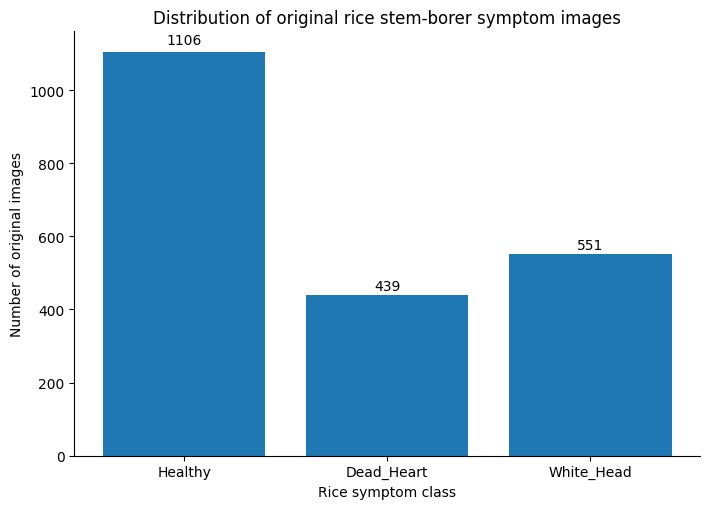

Table 1. Distribution of original images by symptom class


,class_name,Number_of_images,Percentage
0,Healthy,1106,52.77
1,Dead_Heart,439,20.94
2,White_Head,551,26.29


In [16]:
# Cell 16: Class-distribution figure and table

class_distribution_table = (
    clean_manifest_df.groupby("class_name")
    .size()
    .rename("Number_of_images")
    .reset_index()
)

class_order = ["Healthy", "Dead_Heart", "White_Head"]

class_distribution_table["class_name"] = pd.Categorical(
    class_distribution_table["class_name"],
    categories=class_order,
    ordered=True
)

class_distribution_table = (
    class_distribution_table
    .sort_values("class_name")
    .reset_index(drop=True)
)

class_distribution_table["Percentage"] = (
    class_distribution_table["Number_of_images"]
    / class_distribution_table["Number_of_images"].sum()
    * 100
).round(2)

fig, ax = plt.subplots(figsize=(7.2, 5.2))

bars = ax.bar(
    class_distribution_table["class_name"].astype(str),
    class_distribution_table["Number_of_images"]
)

ax.set_xlabel("Rice symptom class")
ax.set_ylabel("Number of original images")
ax.set_title("Distribution of original rice stem-borer symptom images")

for bar, count in zip(
    bars,
    class_distribution_table["Number_of_images"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(5, count * 0.01),
        str(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

figure_path = FIGURE_DIR / "Figure_1_class_distribution.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

print("Table 1. Distribution of original images by symptom class")
display(class_distribution_table)

class_distribution_table.to_csv(
    TABLE_DIR / "Table_1_class_distribution.csv",
    index=False
)

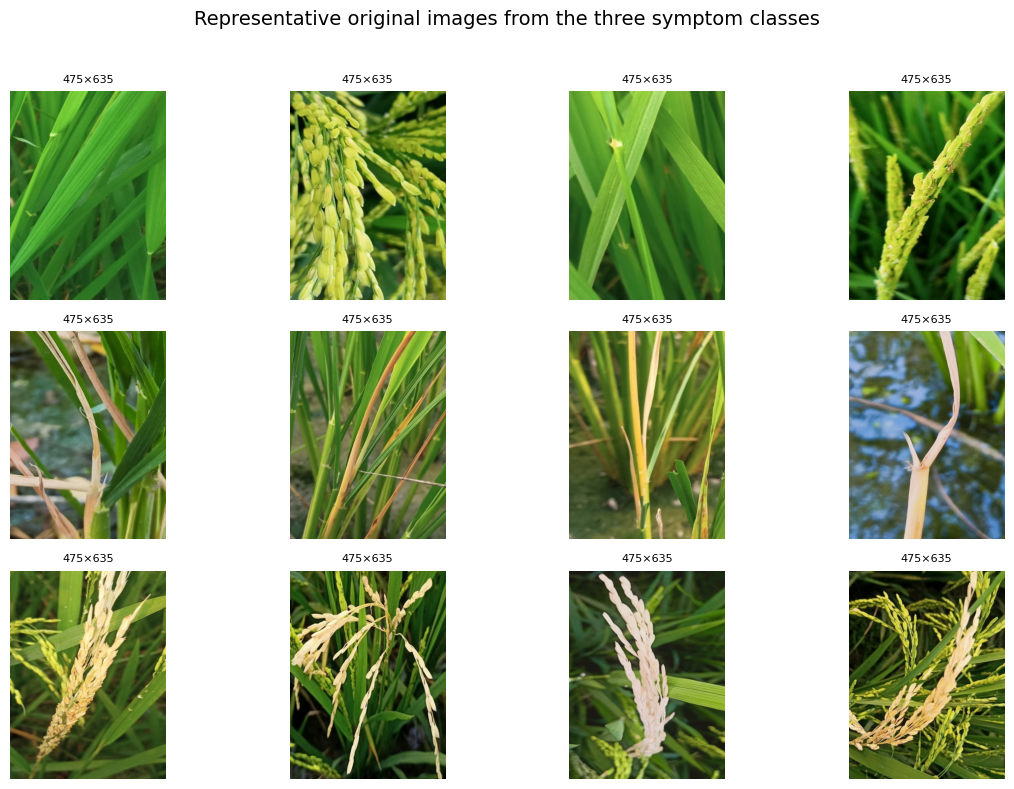

Table 2. Metadata for representative images shown above


,class_name,filename,width,height,file_size_kb
0,Dead_Heart,Dead_heart332.jpg,475,635,83.67
1,Dead_Heart,Dead_heart148.jpg,475,635,96.00
2,Dead_Heart,Dead_heart407.jpg,475,635,75.57
3,Dead_Heart,Dead_heart323.jpg,475,635,80.30
4,Healthy,Healthy (1430).jpg,475,635,68.86
5,Healthy,Healthy (1839).jpg,475,635,100.47
6,Healthy,Healthy (1163).jpg,475,635,59.12
7,Healthy,Healthy (1800).jpg,475,635,77.47
8,White_Head,WhiteHead95.jpg,475,635,91.17
9,White_Head,WhiteHead172.jpg,475,635,112.71


In [17]:
# Cell 17: Display representative original images

N_SAMPLES_PER_CLASS = 4

sampled_images = (
    clean_manifest_df.groupby("class_name", group_keys=False)
    .apply(
        lambda group: group.sample(
            n=min(N_SAMPLES_PER_CLASS, len(group)),
            random_state=SEED
        )
    )
    .reset_index(drop=True)
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=N_SAMPLES_PER_CLASS,
    figsize=(12, 8)
)

for row_index, class_name in enumerate(class_order):
    class_samples = sampled_images[
        sampled_images["class_name"] == class_name
    ].reset_index(drop=True)

    for column_index in range(N_SAMPLES_PER_CLASS):
        ax = axes[row_index, column_index]
        ax.axis("off")

        if column_index < len(class_samples):
            image_row = class_samples.iloc[column_index]

            with Image.open(image_row["filepath"]) as image:
                ax.imshow(image.convert("RGB"))

            if column_index == 0:
                ax.set_ylabel(
                    class_name.replace("_", " "),
                    fontsize=11
                )

            ax.set_title(
                f"{image_row['width']}×{image_row['height']}",
                fontsize=8
            )

fig.suptitle(
    "Representative original images from the three symptom classes",
    fontsize=14
)
fig.tight_layout(rect=[0, 0, 1, 0.96])

figure_path = FIGURE_DIR / "Figure_2_representative_images.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

representative_table = sampled_images[
    ["class_name", "filename", "width", "height", "file_size_kb"]
].copy()

representative_table["file_size_kb"] = (
    representative_table["file_size_kb"].round(2)
)

print("Table 2. Metadata for representative images shown above")
display(representative_table)

representative_table.to_csv(
    TABLE_DIR / "Table_2_representative_images.csv",
    index=False
)

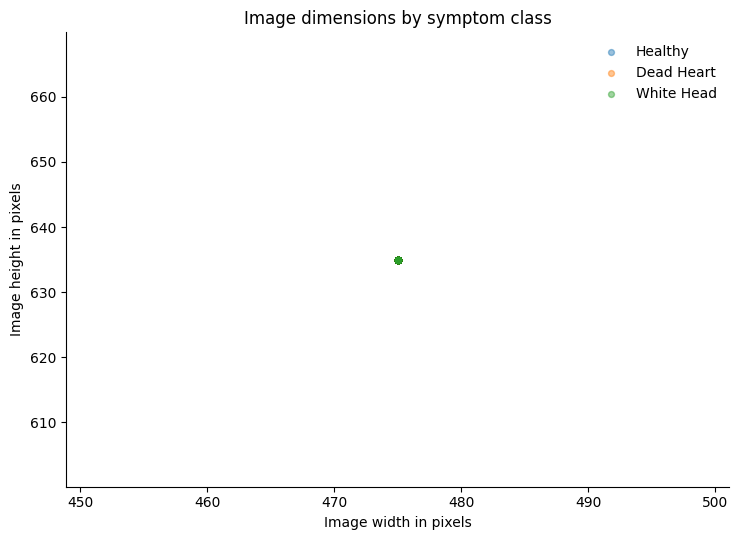

Table 3. Image-dimension summary


,class_name,Images,Mean_width,SD_width,Mean_height,SD_height,Mean_aspect_ratio
0,Dead_Heart,439,475.0,0.0,635.0,0.0,0.75
1,Healthy,1106,475.0,0.0,635.0,0.0,0.75
2,White_Head,551,475.0,0.0,635.0,0.0,0.75


In [18]:
# Cell 18: Image-resolution analysis

dimension_table = (
    clean_manifest_df.groupby("class_name")
    .agg(
        Images=("filepath", "count"),
        Mean_width=("width", "mean"),
        SD_width=("width", "std"),
        Mean_height=("height", "mean"),
        SD_height=("height", "std"),
        Mean_aspect_ratio=("aspect_ratio", "mean")
    )
    .reset_index()
)

numeric_columns = dimension_table.select_dtypes(
    include=np.number
).columns

dimension_table[numeric_columns] = (
    dimension_table[numeric_columns].round(2)
)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

for class_name in class_order:
    subset = clean_manifest_df[
        clean_manifest_df["class_name"] == class_name
    ]

    ax.scatter(
        subset["width"],
        subset["height"],
        alpha=0.45,
        s=18,
        label=class_name.replace("_", " ")
    )

ax.set_xlabel("Image width in pixels")
ax.set_ylabel("Image height in pixels")
ax.set_title("Image dimensions by symptom class")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

figure_path = FIGURE_DIR / "Figure_3_image_dimensions.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

print("Table 3. Image-dimension summary")
display(dimension_table)

dimension_table.to_csv(
    TABLE_DIR / "Table_3_image_dimensions.csv",
    index=False
)

In [19]:
# Cell 19: Leakage-safe stratified dataset splitting

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert math.isclose(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO,
    1.0
)

train_df, temporary_df = train_test_split(
    clean_manifest_df,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=clean_manifest_df["class_name"],
    random_state=SEED
)

relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temporary_df,
    test_size=relative_test_ratio,
    stratify=temporary_df["class_name"],
    random_state=SEED
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

split_manifest_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print(split_manifest_df.groupby(
    ["split", "class_name"]
).size().unstack(fill_value=0))

print("\nSplit totals:")
print(split_manifest_df["split"].value_counts())

class_name  Dead_Heart  Healthy  White_Head
split                                      
test                66      166          83
train              307      774         386
val                 66      166          82

Split totals:
split
train    1467
test      315
val       314
Name: count, dtype: int64


In [20]:
# Cell 20: Verify no exact image occurs in multiple partitions

hash_split_counts = (
    split_manifest_df.groupby("sha256")["split"]
    .nunique()
)

leaking_hashes = hash_split_counts[
    hash_split_counts > 1
]

print("Exact-hash leakage groups:", len(leaking_hashes))

if len(leaking_hashes) > 0:
    raise RuntimeError(
        "Exact duplicate leakage was found across partitions."
    )

filepath_split_counts = (
    split_manifest_df.groupby("filepath")["split"]
    .nunique()
)

if (filepath_split_counts > 1).any():
    raise RuntimeError(
        "The same filepath occurs in more than one partition."
    )

print("Leakage checks passed.")

Exact-hash leakage groups: 0
Leakage checks passed.


In [21]:
# Cell 21: Prepare Ultralytics classification directory structure

if PREPARED_DIR.exists():
    shutil.rmtree(PREPARED_DIR)

for split_name in ["train", "val", "test"]:
    for class_name in class_order:
        (
            PREPARED_DIR / split_name / class_name
        ).mkdir(parents=True, exist_ok=True)

copy_records = []

for row_index, row in split_manifest_df.iterrows():
    source_path = Path(row["filepath"])

    # Prefix with hash to avoid accidental filename collision.
    destination_filename = (
        f"{row['sha256'][:12]}_{source_path.name}"
    )

    destination_path = (
        PREPARED_DIR
        / row["split"]
        / row["class_name"]
        / destination_filename
    )

    shutil.copy2(source_path, destination_path)

    copy_records.append({
        "source_path": str(source_path),
        "prepared_path": str(destination_path),
        "split": row["split"],
        "class_name": row["class_name"],
        "sha256": row["sha256"]
    })

prepared_manifest_df = pd.DataFrame(copy_records)

prepared_manifest_df.to_csv(
    PROJECT_ROOT / "prepared_dataset_manifest.csv",
    index=False
)

print("Prepared dataset:", PREPARED_DIR)
print("\nPrepared counts:")

display(
    prepared_manifest_df.groupby(
        ["split", "class_name"]
    ).size().unstack(fill_value=0)
)

Prepared dataset: /content/rice_stem_borer_research/prepared_dataset

Prepared counts:


class_name,Dead_Heart,Healthy,White_Head
split,,,
test,66,166,83
train,307,774,386
val,66,166,82


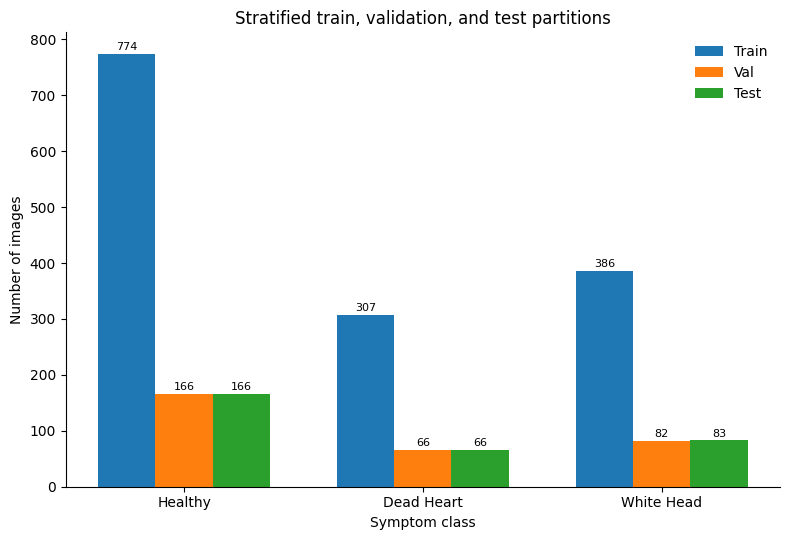

Table 4. Distribution of images across data partitions


split,class_name,train,val,test,Total
0,Healthy,774,166,166,1106
1,Dead_Heart,307,66,66,439
2,White_Head,386,82,83,551


In [22]:
# Cell 22: Train-validation-test distribution figure

split_distribution_table = (
    prepared_manifest_df.groupby(["split", "class_name"])
    .size()
    .rename("Number_of_images")
    .reset_index()
)

split_order = ["train", "val", "test"]

pivot_split = (
    split_distribution_table.pivot(
        index="class_name",
        columns="split",
        values="Number_of_images"
    )
    .reindex(index=class_order, columns=split_order)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(8, 5.5))

x_positions = np.arange(len(class_order))
bar_width = 0.24

for split_index, split_name in enumerate(split_order):
    offset = (
        split_index - (len(split_order) - 1) / 2
    ) * bar_width

    bars = ax.bar(
        x_positions + offset,
        pivot_split[split_name].values,
        width=bar_width,
        label=split_name.capitalize()
    )

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            f"{int(bar.get_height())}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(x_positions)
ax.set_xticklabels([
    class_name.replace("_", " ")
    for class_name in class_order
])
ax.set_xlabel("Symptom class")
ax.set_ylabel("Number of images")
ax.set_title("Stratified train, validation, and test partitions")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

figure_path = FIGURE_DIR / "Figure_4_split_distribution.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

split_table_for_display = pivot_split.reset_index()
split_table_for_display["Total"] = (
    split_table_for_display[split_order].sum(axis=1)
)

print("Table 4. Distribution of images across data partitions")
display(split_table_for_display)

split_table_for_display.to_csv(
    TABLE_DIR / "Table_4_split_distribution.csv",
    index=False
)

In [23]:
# Cell 23: Model and training configuration
# Compatible with GPU-enabled Colab runtimes.
# Note: a v5e-1 TPU is not directly used by the standard Ultralytics trainer.

import torch
import os
import platform

# ---------------------------------------------------------
# 1. Model configurations
# ---------------------------------------------------------
MODEL_CONFIGS = {
    "YOLO11n-cls": {
        "checkpoint": "yolo11n-cls.pt",
        "batch": -1
    },
    "YOLO26n-cls": {
        "checkpoint": "yolo26n-cls.pt",
        "batch": -1
    },
    "YOLO26s-cls": {
        "checkpoint": "yolo26s-cls.pt",
        "batch": -1
    }
}

# ---------------------------------------------------------
# 2. Training configuration
# ---------------------------------------------------------
EPOCHS = 25
IMAGE_SIZE = 320
PATIENCE = 8
NUM_WORKERS = 4

# Enable automatic mixed precision for faster GPU training.
AMP = True

# Cache decoded images on disk to reduce repeated read overhead.
CACHE_MODE = "disk"

# ---------------------------------------------------------
# 3. Device detection
# ---------------------------------------------------------
if torch.cuda.is_available():
    DEVICE = 0
    DEVICE_TYPE = "CUDA GPU"
    DEVICE_NAME = torch.cuda.get_device_name(0)

else:
    DEVICE = "cpu"
    DEVICE_TYPE = "CPU"
    DEVICE_NAME = platform.processor() or "CPU"

# Detect whether the environment appears to be a TPU runtime.
TPU_ENVIRONMENT = any(
    key in os.environ
    for key in [
        "COLAB_TPU_ADDR",
        "TPU_NAME",
        "XRT_TPU_CONFIG"
    ]
)

# ---------------------------------------------------------
# 4. Runtime warning
# ---------------------------------------------------------
if TPU_ENVIRONMENT and not torch.cuda.is_available():
    print("=" * 80)
    print("WARNING")
    print("=" * 80)
    print(
        "A TPU runtime appears to be selected, but the standard "
        "Ultralytics trainer does not use the TPU through device=0."
    )
    print(
        "Training will fall back to the CPU and may be extremely slow."
    )
    print(
        "For this notebook, change the Colab accelerator to an "
        "NVIDIA GPU such as T4, L4, A100, or H100."
    )
    print("=" * 80)

# ---------------------------------------------------------
# 5. Display configurations
# ---------------------------------------------------------
print("\nModels")

for model_name, configuration in MODEL_CONFIGS.items():
    print(
        f"  {model_name:<15} "
        f"checkpoint={configuration['checkpoint']}, "
        f"batch={configuration['batch']}"
    )

print("\nTraining configuration")
print(f"Epochs       : {EPOCHS}")
print(f"Image size   : {IMAGE_SIZE}")
print(f"Patience     : {PATIENCE}")
print(f"Workers      : {NUM_WORKERS}")
print(f"AMP          : {AMP}")
print(f"Cache mode   : {CACHE_MODE}")

print("\nRuntime configuration")
print(f"Device       : {DEVICE}")
print(f"Device type  : {DEVICE_TYPE}")
print(f"Device name  : {DEVICE_NAME}")
print(f"CUDA         : {torch.cuda.is_available()}")
print(f"TPU detected : {TPU_ENVIRONMENT}")

if torch.cuda.is_available():
    total_memory_gb = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(
        f"GPU memory   : {total_memory_gb:.2f} GB"
    )


Models
  YOLO11n-cls     checkpoint=yolo11n-cls.pt, batch=-1
  YOLO26n-cls     checkpoint=yolo26n-cls.pt, batch=-1
  YOLO26s-cls     checkpoint=yolo26s-cls.pt, batch=-1

Training configuration
Epochs       : 25
Image size   : 320
Patience     : 8
Workers      : 4
AMP          : True
Cache mode   : disk

Runtime configuration
Device       : 0
Device type  : CUDA GPU
Device name  : Tesla T4
CUDA         : True
TPU detected : False
GPU memory   : 14.56 GB


In [24]:
# Cell 24: Save complete reproducibility metadata

import json
import platform
import datetime
import torch
import ultralytics

# ---------------------------------------------------------
# Prepare serializable model configuration
# ---------------------------------------------------------
serializable_model_configs = {
    model_name: {
        "checkpoint": configuration["checkpoint"],
        "batch": configuration["batch"]
    }
    for model_name, configuration in MODEL_CONFIGS.items()
}

# ---------------------------------------------------------
# Collect GPU information safely
# ---------------------------------------------------------
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)

    gpu_total_memory_gb = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    cuda_version = torch.version.cuda

else:
    gpu_name = None
    gpu_total_memory_gb = None
    cuda_version = None

# ---------------------------------------------------------
# Complete experiment configuration
# ---------------------------------------------------------
experiment_configuration = {
    "experiment_name": (
        "Rice stem-borer symptom classification using "
        "Ultralytics classifiers"
    ),

    "created_at": datetime.datetime.now().isoformat(),

    "dataset": {
        "dataset_url": DATASET_URL,
        "dataset_doi": "10.17632/hnfjs42d5g.1",
        "dataset_root": str(ORIGINAL_DATA_ROOT),
        "prepared_dataset": str(PREPARED_DIR),
        "classes": [
            "Healthy",
            "Dead_Heart",
            "White_Head"
        ]
    },

    "reproducibility": {
        "seed": SEED,
        "deterministic": True
    },

    "split_ratios": {
        "train": TRAIN_RATIO,
        "validation": VAL_RATIO,
        "test": TEST_RATIO
    },

    "models": serializable_model_configs,

    "training": {
        "epochs": EPOCHS,
        "image_size": IMAGE_SIZE,
        "patience": PATIENCE,
        "workers": NUM_WORKERS,
        "automatic_mixed_precision": AMP,
        "cache_mode": CACHE_MODE,
        "pretrained": True,
        "optimizer": "auto"
    },

    "runtime": {
        "device_argument": str(DEVICE),
        "device_type": DEVICE_TYPE,
        "device_name": DEVICE_NAME,
        "tpu_environment_detected": TPU_ENVIRONMENT,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": cuda_version,
        "gpu_name": gpu_name,
        "gpu_total_memory_gb": (
            round(gpu_total_memory_gb, 3)
            if gpu_total_memory_gb is not None
            else None
        )
    },

    "software": {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "pytorch_version": torch.__version__,
        "ultralytics_version": ultralytics.__version__
    }
}

# ---------------------------------------------------------
# Save configuration as JSON
# ---------------------------------------------------------
configuration_path = (
    PROJECT_ROOT / "experiment_configuration.json"
)

with open(
    configuration_path,
    "w",
    encoding="utf-8"
) as file_handle:
    json.dump(
        experiment_configuration,
        file_handle,
        indent=4,
        ensure_ascii=False
    )

print("Experiment configuration saved to:")
print(configuration_path)

experiment_configuration

Experiment configuration saved to:
/content/rice_stem_borer_research/experiment_configuration.json


{'experiment_name': 'Rice stem-borer symptom classification using Ultralytics classifiers',
 'created_at': '2026-07-31T10:19:52.763415',
 'dataset': {'dataset_url': 'https://data.mendeley.com/public-files/datasets/hnfjs42d5g/files/6f46fe33-4cbb-44d1-a149-61dd3fe4eec7/file_downloaded',
  'dataset_doi': '10.17632/hnfjs42d5g.1',
  'dataset_root': '/content/rice_stem_borer_research/extracted/Stem Borer Infestation Dataset/Original Dataset',
  'prepared_dataset': '/content/rice_stem_borer_research/prepared_dataset',
  'classes': ['Healthy', 'Dead_Heart', 'White_Head']},
 'reproducibility': {'seed': 42, 'deterministic': True},
 'split_ratios': {'train': 0.7, 'validation': 0.15, 'test': 0.15},
 'models': {'YOLO11n-cls': {'checkpoint': 'yolo11n-cls.pt', 'batch': -1},
  'YOLO26n-cls': {'checkpoint': 'yolo26n-cls.pt', 'batch': -1},
  'YOLO26s-cls': {'checkpoint': 'yolo26s-cls.pt', 'batch': -1}},
 'training': {'epochs': 25,
  'image_size': 320,
  'patience': 8,
  'workers': 4,
  'automatic_mixed_

In [25]:
# Cell 25: Train comparative Ultralytics classification models

training_summary_records = []
trained_model_paths = {}

for experiment_name, configuration in MODEL_CONFIGS.items():

    checkpoint = configuration["checkpoint"]
    model_batch_size = configuration["batch"]

    print("=" * 90)
    print(f"Training model : {experiment_name}")
    print(f"Checkpoint     : {checkpoint}")
    print(f"Batch size     : {model_batch_size}")
    print(f"Image size     : {IMAGE_SIZE}")
    print(f"Maximum epochs : {EPOCHS}")
    print(f"Device         : {DEVICE}")
    print("=" * 90)

    # -----------------------------------------------------
    # Release unused memory before loading the next model
    # -----------------------------------------------------
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # -----------------------------------------------------
    # Load pretrained classification model
    # -----------------------------------------------------
    model = YOLO(checkpoint)

    start_time = time.perf_counter()

    # -----------------------------------------------------
    # Train model
    # -----------------------------------------------------
    try:
        training_results = model.train(
            data=str(PREPARED_DIR),

            epochs=EPOCHS,
            imgsz=IMAGE_SIZE,
            batch=model_batch_size,
            patience=PATIENCE,

            device=DEVICE,
            workers=NUM_WORKERS,

            seed=SEED,
            deterministic=True,
            pretrained=True,

            optimizer="auto",
            lr0=0.001,
            lrf=0.01,
            weight_decay=0.0005,
            warmup_epochs=3.0,

            amp=AMP,
            cache=CACHE_MODE,

            # ---------------------------------------------
            # Online augmentation applied only to training
            # ---------------------------------------------
            hsv_h=0.015,
            hsv_s=0.30,
            hsv_v=0.30,
            degrees=15.0,
            translate=0.10,
            scale=0.20,
            shear=5.0,
            fliplr=0.50,
            flipud=0.00,
            erasing=0.20,
            auto_augment="randaugment",

            # ---------------------------------------------
            # Output configuration
            # ---------------------------------------------
            project=str(MODEL_DIR),
            name=experiment_name,
            exist_ok=True,
            plots=True,
            save=True,
            save_period=-1,
            verbose=True
        )

    except RuntimeError as error:

        error_message = str(error).lower()

        # Automatic fallback when GPU memory is insufficient
        if (
            "out of memory" in error_message
            or "cuda out of memory" in error_message
        ):
            print("\nCUDA out-of-memory error detected.")
            print(
                "Retrying this model with automatic batch selection "
                "and reduced memory pressure."
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            model = YOLO(checkpoint)

            training_results = model.train(
                data=str(PREPARED_DIR),

                epochs=EPOCHS,
                imgsz=IMAGE_SIZE,
                batch=-1,
                patience=PATIENCE,

                device=DEVICE,
                workers=max(2, NUM_WORKERS // 2),

                seed=SEED,
                deterministic=True,
                pretrained=True,

                optimizer="auto",
                lr0=0.001,
                lrf=0.01,
                weight_decay=0.0005,
                warmup_epochs=3.0,

                amp=AMP,
                cache=CACHE_MODE,

                hsv_h=0.015,
                hsv_s=0.30,
                hsv_v=0.30,
                degrees=15.0,
                translate=0.10,
                scale=0.20,
                shear=5.0,
                fliplr=0.50,
                flipud=0.00,
                erasing=0.20,
                auto_augment="randaugment",

                project=str(MODEL_DIR),
                name=experiment_name,
                exist_ok=True,
                plots=True,
                save=True,
                save_period=-1,
                verbose=True
            )

            model_batch_size = -1

        else:
            raise error

    training_time_seconds = (
        time.perf_counter() - start_time
    )

    # -----------------------------------------------------
    # Locate saved model weights
    # -----------------------------------------------------
    best_model_path = (
        MODEL_DIR
        / experiment_name
        / "weights"
        / "best.pt"
    )

    last_model_path = (
        MODEL_DIR
        / experiment_name
        / "weights"
        / "last.pt"
    )

    results_csv_path = (
        MODEL_DIR
        / experiment_name
        / "results.csv"
    )

    if not best_model_path.exists():
        raise FileNotFoundError(
            f"Best model was not found: {best_model_path}"
        )

    trained_model_paths[experiment_name] = str(
        best_model_path
    )

    # -----------------------------------------------------
    # Read completed epochs and best validation result
    # -----------------------------------------------------
    completed_epochs = None
    best_validation_top1 = None
    final_training_loss = None
    final_validation_loss = None

    if results_csv_path.exists():

        temporary_results_df = pd.read_csv(
            results_csv_path
        )

        temporary_results_df.columns = [
            column.strip()
            for column in temporary_results_df.columns
        ]

        completed_epochs = len(
            temporary_results_df
        )

        top1_candidates = [
            column
            for column in temporary_results_df.columns
            if "top1" in column.lower().replace(" ", "")
        ]

        train_loss_candidates = [
            column
            for column in temporary_results_df.columns
            if (
                "train" in column.lower()
                and "loss" in column.lower()
            )
        ]

        val_loss_candidates = [
            column
            for column in temporary_results_df.columns
            if (
                "val" in column.lower()
                and "loss" in column.lower()
            )
        ]

        if top1_candidates:
            best_validation_top1 = float(
                temporary_results_df[
                    top1_candidates[0]
                ].max()
            )

        if train_loss_candidates:
            final_training_loss = float(
                temporary_results_df[
                    train_loss_candidates[0]
                ].iloc[-1]
            )

        if val_loss_candidates:
            final_validation_loss = float(
                temporary_results_df[
                    val_loss_candidates[0]
                ].iloc[-1]
            )

    # -----------------------------------------------------
    # Save model-level training summary
    # -----------------------------------------------------
    training_summary_records.append({
        "Model": experiment_name,
        "Initial_checkpoint": checkpoint,
        "Best_model_path": str(best_model_path),
        "Last_model_path": str(last_model_path),
        "Results_csv_path": str(results_csv_path),
        "Training_time_minutes":
            training_time_seconds / 60,
        "Image_size": IMAGE_SIZE,
        "Batch_size": model_batch_size,
        "Maximum_epochs": EPOCHS,
        "Completed_epochs": completed_epochs,
        "Patience": PATIENCE,
        "AMP": AMP,
        "Cache_mode": CACHE_MODE,
        "Workers": NUM_WORKERS,
        "Best_validation_top1":
            best_validation_top1,
        "Final_training_loss":
            final_training_loss,
        "Final_validation_loss":
            final_validation_loss,
        "Device": str(DEVICE),
        "GPU_name": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        )
    })

    print("\nTraining completed")
    print(
        f"Time taken: "
        f"{training_time_seconds / 60:.2f} minutes"
    )
    print(f"Best model: {best_model_path}")

    if best_validation_top1 is not None:
        print(
            f"Best validation top-1 accuracy: "
            f"{best_validation_top1:.4f}"
        )

    # Release memory before the next model
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ---------------------------------------------------------
# Create and save comparative training summary
# ---------------------------------------------------------
training_summary_df = pd.DataFrame(
    training_summary_records
)

numeric_columns = training_summary_df.select_dtypes(
    include=np.number
).columns

training_summary_df[numeric_columns] = (
    training_summary_df[numeric_columns].round(4)
)

training_summary_path = (
    TABLE_DIR / "Table_5_training_summary.csv"
)

training_summary_df.to_csv(
    training_summary_path,
    index=False
)

print("\n" + "=" * 90)
print("COMPARATIVE TRAINING SUMMARY")
print("=" * 90)

display(training_summary_df)

print("\nTraining summary saved to:")
print(training_summary_path)

Training model : YOLO11n-cls
Checkpoint     : yolo11n-cls.pt
Batch size     : -1
Image size     : 320
Maximum epochs : 25
Device         : 0
Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=disk, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rice_stem_borer_research/prepared_dataset, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.3, hsv_v=0.3, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00

,Model,Initial_checkpoint,Best_model_path,Last_model_path,Results_csv_path,Training_time_minutes,Image_size,Batch_size,Maximum_epochs,Completed_epochs,Patience,AMP,Cache_mode,Workers,Best_validation_top1,Final_training_loss,Final_validation_loss,Device,GPU_name
0,YOLO11n-cls,yolo11n-cls.pt,/content/rice_stem_borer_research/results/trai...,/content/rice_stem_borer_research/results/trai...,/content/rice_stem_borer_research/results/trai...,4.3798,320,-1,25,12,8,True,disk,4,0.9936,0.0152,0.0370,0,Tesla T4
1,YOLO26n-cls,yolo26n-cls.pt,/content/rice_stem_borer_research/results/trai...,/content/rice_stem_borer_research/results/trai...,/content/rice_stem_borer_research/results/trai...,4.7001,320,-1,25,14,8,True,disk,4,1.0000,0.0264,0.0097,0,Tesla T4
2,YOLO26s-cls,yolo26s-cls.pt,/content/rice_stem_borer_research/results/trai...,/content/rice_stem_borer_research/results/trai...,/content/rice_stem_borer_research/results/trai...,3.7481,320,-1,25,10,8,True,disk,4,1.0000,0.0220,0.0108,0,Tesla T4



Training summary saved to:
/content/rice_stem_borer_research/results/tables/Table_5_training_summary.csv


In [26]:
# Cell 26: Consolidated training-history figure

history_records = []

for experiment_name in MODEL_CONFIGS:
    results_csv = (
        MODEL_DIR
        / experiment_name
        / "results.csv"
    )

    if not results_csv.exists():
        print(f"Missing history: {results_csv}")
        continue

    history_df = pd.read_csv(results_csv)
    history_df.columns = [
        column.strip()
        for column in history_df.columns
    ]

    history_df["Model"] = experiment_name
    history_records.append(history_df)

if not history_records:
    raise RuntimeError("No training-history files were found.")

combined_history_df = pd.concat(
    history_records,
    ignore_index=True
)

print("Available history columns:")
print(combined_history_df.columns.tolist())

Available history columns:
['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'Model']


In [27]:
# Cell 26B: Automatically identify classification history columns

def find_column(columns, include_terms, exclude_terms=None):
    exclude_terms = exclude_terms or []

    for column in columns:
        normalized = column.lower().replace(" ", "")

        if all(term.lower() in normalized for term in include_terms):
            if not any(
                term.lower() in normalized
                for term in exclude_terms
            ):
                return column

    return None

history_columns = combined_history_df.columns.tolist()

epoch_column = find_column(history_columns, ["epoch"])
train_loss_column = find_column(
    history_columns,
    ["train", "loss"]
)
val_loss_column = find_column(
    history_columns,
    ["val", "loss"]
)
top1_column = find_column(
    history_columns,
    ["top1"]
)
top5_column = find_column(
    history_columns,
    ["top5"]
)

print("Epoch column     :", epoch_column)
print("Train-loss column:", train_loss_column)
print("Val-loss column  :", val_loss_column)
print("Top-1 column     :", top1_column)
print("Top-5 column     :", top5_column)

Epoch column     : epoch
Train-loss column: train/loss
Val-loss column  : val/loss
Top-1 column     : metrics/accuracy_top1
Top-5 column     : metrics/accuracy_top5


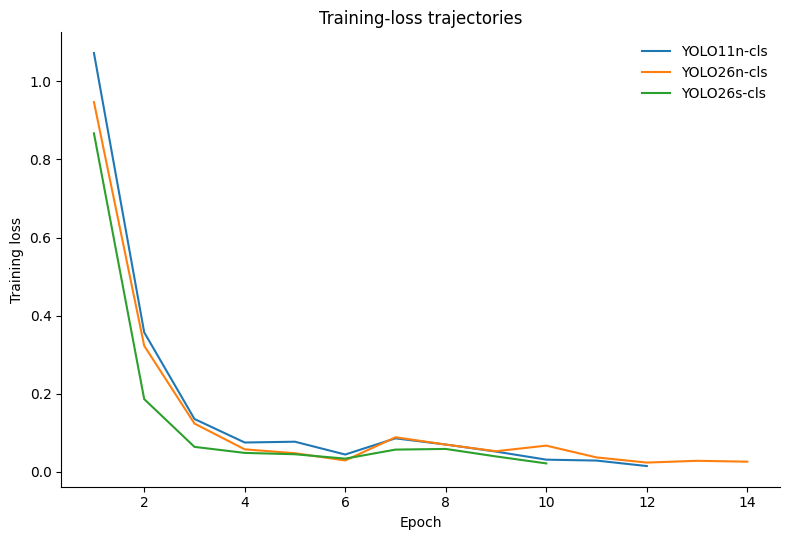

Table 5A. Training-history summary


,Model,Completed_epochs,Final_training_loss,Final_validation_loss,Best_validation_top1,Best_validation_top5
0,YOLO11n-cls,12,0.0152,0.0370,0.9936,1
1,YOLO26n-cls,14,0.0264,0.0097,1.0000,1
2,YOLO26s-cls,10,0.0220,0.0108,1.0000,1


In [28]:
# Cell 26C: Create 600-dpi training-history figures

history_summary_rows = []

if epoch_column and train_loss_column:
    fig, ax = plt.subplots(figsize=(8, 5.5))

    for model_name in MODEL_CONFIGS:
        subset = combined_history_df[
            combined_history_df["Model"] == model_name
        ]

        ax.plot(
            subset[epoch_column],
            subset[train_loss_column],
            label=model_name
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training loss")
    ax.set_title("Training-loss trajectories")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    fig.savefig(
        FIGURE_DIR / "Figure_5_training_loss.png",
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()

for model_name in MODEL_CONFIGS:
    subset = combined_history_df[
        combined_history_df["Model"] == model_name
    ].copy()

    summary_row = {
        "Model": model_name,
        "Completed_epochs": len(subset)
    }

    if train_loss_column:
        summary_row["Final_training_loss"] = (
            subset[train_loss_column].iloc[-1]
        )

    if val_loss_column:
        summary_row["Final_validation_loss"] = (
            subset[val_loss_column].iloc[-1]
        )

    if top1_column:
        summary_row["Best_validation_top1"] = (
            subset[top1_column].max()
        )

    if top5_column:
        summary_row["Best_validation_top5"] = (
            subset[top5_column].max()
        )

    history_summary_rows.append(summary_row)

history_summary_df = pd.DataFrame(history_summary_rows)

numeric_columns = history_summary_df.select_dtypes(
    include=np.number
).columns

history_summary_df[numeric_columns] = (
    history_summary_df[numeric_columns].round(4)
)

print("Table 5A. Training-history summary")
display(history_summary_df)

history_summary_df.to_csv(
    TABLE_DIR / "Table_5A_training_history_summary.csv",
    index=False
)

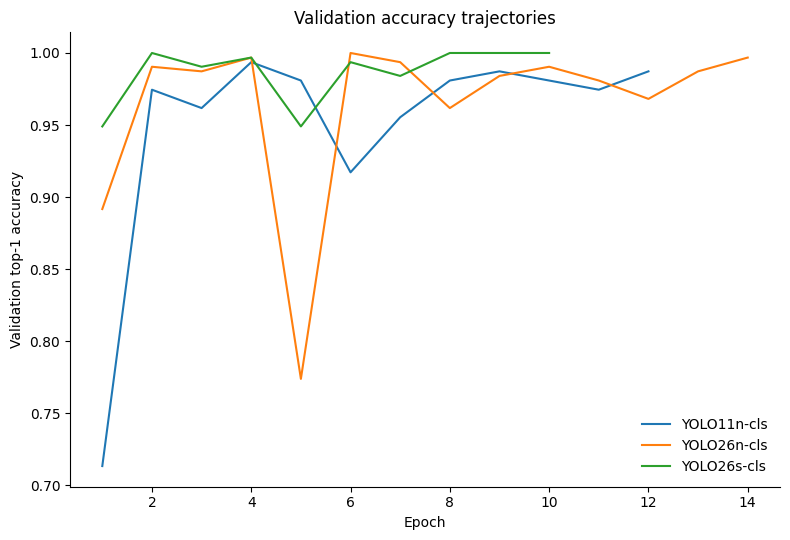

Table 5B. Best validation accuracy by model


,Model,Completed_epochs,Best_validation_top1
0,YOLO11n-cls,12,0.9936
1,YOLO26n-cls,14,1.0000
2,YOLO26s-cls,10,1.0000


In [29]:
# Cell 26D: Validation accuracy trajectory

if epoch_column and top1_column:
    fig, ax = plt.subplots(figsize=(8, 5.5))

    for model_name in MODEL_CONFIGS:
        subset = combined_history_df[
            combined_history_df["Model"] == model_name
        ]

        ax.plot(
            subset[epoch_column],
            subset[top1_column],
            label=model_name
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation top-1 accuracy")
    ax.set_title("Validation accuracy trajectories")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    fig.savefig(
        FIGURE_DIR / "Figure_6_validation_accuracy.png",
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()

    print("Table 5B. Best validation accuracy by model")

    validation_accuracy_table = (
        history_summary_df[
            [
                "Model",
                "Completed_epochs",
                "Best_validation_top1"
            ]
        ]
        if "Best_validation_top1" in history_summary_df.columns
        else history_summary_df
    )

    display(validation_accuracy_table)

In [37]:
# Cell 27: Independent test-set inference with preserved true labels

TEST_DIRECTORY = PREPARED_DIR / "test"

INFERENCE_BATCH_SIZE = 64 if torch.cuda.is_available() else 8

SUPPORTED_IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp",
    ".heic", ".heif", ".dng",
    ".mpo", ".jp2", ".avif"
}


def predict_classification_dataset(
    model_path,
    source_directory,
    image_size,
    batch_size,
    device
):
    """
    Run classification inference on all test images while preserving
    each image's original filepath and ground-truth class.

    Important:
    Ultralytics may return generic result paths such as image0.jpg
    when a Python list is supplied. Therefore, predictions are paired
    with the original input paths by position.
    """

    model_path = Path(model_path)
    source_directory = Path(source_directory)

    if not model_path.exists():
        raise FileNotFoundError(
            f"Model checkpoint not found: {model_path}"
        )

    if not source_directory.exists():
        raise FileNotFoundError(
            f"Test directory not found: {source_directory}"
        )

    # -----------------------------------------------------
    # Collect all test images recursively
    # -----------------------------------------------------
    test_image_paths = sorted([
        path.resolve()
        for path in source_directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_IMAGE_EXTENSIONS
    ])

    if len(test_image_paths) == 0:
        raise FileNotFoundError(
            f"No test images were found inside:\n"
            f"{source_directory}"
        )

    # Ground-truth labels come from the class folder names.
    true_labels = [
        path.parent.name
        for path in test_image_paths
    ]

    class_count_table = (
        pd.Series(true_labels, name="true_class")
        .value_counts()
        .sort_index()
        .rename("Number_of_images")
        .to_frame()
    )

    print(
        f"Detected {len(test_image_paths)} test images."
    )

    print("\nGround-truth test distribution:")
    display(class_count_table)

    # -----------------------------------------------------
    # Load model
    # -----------------------------------------------------
    model = YOLO(str(model_path))

    # Warm-up before timed inference.
    _ = model.predict(
        source=str(test_image_paths[0]),
        imgsz=image_size,
        device=device,
        verbose=False
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    records = []
    class_names = None

    start_time = time.perf_counter()

    # -----------------------------------------------------
    # Run inference in explicit batches
    # -----------------------------------------------------
    for batch_start in range(
        0,
        len(test_image_paths),
        batch_size
    ):
        batch_paths = test_image_paths[
            batch_start:batch_start + batch_size
        ]

        batch_results = model.predict(
            source=[
                str(path)
                for path in batch_paths
            ],
            imgsz=image_size,
            batch=len(batch_paths),
            device=device,
            stream=False,
            verbose=False
        )

        if len(batch_results) != len(batch_paths):
            raise RuntimeError(
                "The number of predictions does not match "
                "the number of supplied test images.\n"
                f"Supplied: {len(batch_paths)}, "
                f"returned: {len(batch_results)}"
            )

        # Pair each prediction with its original input path.
        for original_path, result in zip(
            batch_paths,
            batch_results
        ):
            true_class_name = original_path.parent.name

            if result.probs is None:
                raise RuntimeError(
                    "Classification probabilities were not returned "
                    f"for image: {original_path}"
                )

            probability_vector = (
                result.probs.data
                .detach()
                .cpu()
                .numpy()
                .astype(float)
            )

            ordered_class_indices = sorted(
                result.names.keys()
            )

            if class_names is None:
                class_names = [
                    result.names[index]
                    for index in ordered_class_indices
                ]

            predicted_index = int(
                np.argmax(probability_vector)
            )

            predicted_class_name = result.names[
                predicted_index
            ]

            record = {
                # Use the original input path, not result.path.
                "filepath": str(original_path),
                "filename": original_path.name,
                "true_class": true_class_name,
                "predicted_class": predicted_class_name,
                "predicted_index": predicted_index,
                "confidence": float(
                    probability_vector[predicted_index]
                )
            }

            for class_index in ordered_class_indices:
                class_name = result.names[class_index]

                record[f"prob_{class_name}"] = float(
                    probability_vector[class_index]
                )

            records.append(record)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    total_inference_seconds = (
        time.perf_counter() - start_time
    )

    prediction_df = pd.DataFrame(records)

    if len(prediction_df) != len(test_image_paths):
        raise RuntimeError(
            "Prediction table length does not match the "
            "number of test images.\n"
            f"Expected: {len(test_image_paths)}, "
            f"obtained: {len(prediction_df)}"
        )

    # Keep the same image order for all models.
    prediction_df = (
        prediction_df
        .sort_values(
            ["true_class", "filepath"]
        )
        .reset_index(drop=True)
    )

    number_of_images = len(prediction_df)

    milliseconds_per_image = (
        total_inference_seconds
        / number_of_images
        * 1000
    )

    images_per_second = (
        number_of_images
        / total_inference_seconds
        if total_inference_seconds > 0
        else np.nan
    )

    # -----------------------------------------------------
    # Verify true labels before returning
    # -----------------------------------------------------
    blank_true_labels = (
        prediction_df["true_class"]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    if blank_true_labels > 0:
        raise RuntimeError(
            f"{blank_true_labels} predictions still have blank "
            "true labels."
        )

    print("\nRecovered true labels:")
    display(
        prediction_df["true_class"]
        .value_counts()
        .sort_index()
        .rename("Number_of_images")
        .to_frame()
    )

    return {
        "model": model,
        "predictions": prediction_df,
        "class_names": class_names,
        "total_inference_seconds":
            total_inference_seconds,
        "milliseconds_per_image":
            milliseconds_per_image,
        "images_per_second":
            images_per_second
    }


# =========================================================
# Run inference for every trained model
# =========================================================

test_prediction_outputs = {}
test_inference_summary_records = []

for experiment_name, model_path in (
    trained_model_paths.items()
):

    print("\n" + "=" * 90)
    print(f"Predicting with : {experiment_name}")
    print(f"Model path      : {model_path}")
    print(f"Image size      : {IMAGE_SIZE}")
    print(f"Inference batch : {INFERENCE_BATCH_SIZE}")
    print(f"Device          : {DEVICE}")
    print("=" * 90)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    output = predict_classification_dataset(
        model_path=model_path,
        source_directory=TEST_DIRECTORY,
        image_size=IMAGE_SIZE,
        batch_size=INFERENCE_BATCH_SIZE,
        device=DEVICE
    )

    test_prediction_outputs[
        experiment_name
    ] = output

    prediction_output_path = (
        TABLE_DIR
        / f"{experiment_name}_test_predictions.csv"
    )

    output["predictions"].to_csv(
        prediction_output_path,
        index=False
    )

    test_inference_summary_records.append({
        "Model": experiment_name,
        "Test_images":
            len(output["predictions"]),
        "Image_size":
            IMAGE_SIZE,
        "Inference_batch_size":
            INFERENCE_BATCH_SIZE,
        "Total_inference_seconds":
            output["total_inference_seconds"],
        "Milliseconds_per_image":
            output["milliseconds_per_image"],
        "Images_per_second":
            output["images_per_second"],
        "Device":
            str(DEVICE),
        "Prediction_file":
            str(prediction_output_path)
    })

    print("\nInference completed")
    print(
        f"Test images            : "
        f"{len(output['predictions'])}"
    )
    print(
        f"Total inference time   : "
        f"{output['total_inference_seconds']:.3f} seconds"
    )
    print(
        f"Average time per image : "
        f"{output['milliseconds_per_image']:.3f} ms"
    )
    print(
        f"Throughput             : "
        f"{output['images_per_second']:.3f} images/second"
    )
    print(
        f"Predictions saved to   : "
        f"{prediction_output_path}"
    )

    # Keep prediction data but remove the loaded model object
    # to release GPU memory.
    test_prediction_outputs[
        experiment_name
    ]["model"] = None

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# =========================================================
# Save inference summary
# =========================================================

test_inference_summary_df = pd.DataFrame(
    test_inference_summary_records
)

numeric_columns = (
    test_inference_summary_df
    .select_dtypes(include=np.number)
    .columns
)

test_inference_summary_df[numeric_columns] = (
    test_inference_summary_df[
        numeric_columns
    ].round(4)
)

inference_summary_path = (
    TABLE_DIR
    / "Table_6_test_inference_summary.csv"
)

test_inference_summary_df.to_csv(
    inference_summary_path,
    index=False
)

print("\n" + "=" * 90)
print("TEST INFERENCE SUMMARY")
print("=" * 90)

display(test_inference_summary_df)

print("\nInference summary saved to:")
print(inference_summary_path)


Predicting with : YOLO11n-cls
Model path      : /content/rice_stem_borer_research/results/trained_models/YOLO11n-cls/weights/best.pt
Image size      : 320
Inference batch : 64
Device          : 0
Detected 315 test images.

Ground-truth test distribution:


,Number_of_images
true_class,
Dead_Heart,66
Healthy,166
White_Head,83



Recovered true labels:


,Number_of_images
true_class,
Dead_Heart,66
Healthy,166
White_Head,83



Inference completed
Test images            : 315
Total inference time   : 9.376 seconds
Average time per image : 29.764 ms
Throughput             : 33.598 images/second
Predictions saved to   : /content/rice_stem_borer_research/results/tables/YOLO11n-cls_test_predictions.csv

Predicting with : YOLO26n-cls
Model path      : /content/rice_stem_borer_research/results/trained_models/YOLO26n-cls/weights/best.pt
Image size      : 320
Inference batch : 64
Device          : 0
Detected 315 test images.

Ground-truth test distribution:


...


Recovered true labels:


,Number_of_images
true_class,
Dead_Heart,66
Healthy,166
White_Head,83



Inference completed
Test images            : 315
Total inference time   : 6.366 seconds
Average time per image : 20.211 ms
Throughput             : 49.479 images/second
Predictions saved to   : /content/rice_stem_borer_research/results/tables/YOLO26s-cls_test_predictions.csv

TEST INFERENCE SUMMARY


,Model,Test_images,Image_size,Inference_batch_size,Total_inference_seconds,Milliseconds_per_image,Images_per_second,Device,Prediction_file
0,YOLO11n-cls,315,320,64,9.3755,29.7636,33.5981,0,/content/rice_stem_borer_research/results/tabl...
1,YOLO26n-cls,315,320,64,3.8946,12.3637,80.8821,0,/content/rice_stem_borer_research/results/tabl...
2,YOLO26s-cls,315,320,64,6.3664,20.2107,49.4787,0,/content/rice_stem_borer_research/results/tabl...



Inference summary saved to:
/content/rice_stem_borer_research/results/tables/Table_6_test_inference_summary.csv


In [39]:
# Cell 28: Comprehensive and label-safe metric calculation

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    log_loss
)

# =========================================================
# 1. Label normalization
# =========================================================

def normalize_class_label(label):
    """
    Convert different representations of the same class into
    the exact class names used by the trained Ultralytics model.
    """

    if label is None:
        return None

    label = str(label).strip()

    if label == "":
        return None

    normalized = (
        label.lower()
        .strip()
        .replace("-", "_")
        .replace(" ", "_")
    )

    normalized = re.sub(
        r"_+",
        "_",
        normalized
    )

    label_mapping = {
        "healthy": "Healthy",
        "dead_heart": "Dead_Heart",
        "deadheart": "Dead_Heart",
        "white_head": "White_Head",
        "whitehead": "White_Head"
    }

    return label_mapping.get(
        normalized,
        label
    )


# =========================================================
# 2. Recover true labels from prepared manifest
# =========================================================

# Build mappings from prepared test-set records.
test_manifest_subset = prepared_manifest_df[
    prepared_manifest_df["split"] == "test"
].copy()

filename_to_true_class = dict(
    zip(
        test_manifest_subset[
            "prepared_path"
        ].apply(lambda path: Path(path).name),
        test_manifest_subset["class_name"]
    )
)

filepath_to_true_class = dict(
    zip(
        test_manifest_subset[
            "prepared_path"
        ].apply(lambda path: str(Path(path).resolve())),
        test_manifest_subset["class_name"]
    )
)


def repair_prediction_true_labels(
    prediction_df,
    model_class_names
):
    """
    Repair blank or inconsistent true labels using:
    1. current true_class value;
    2. full filepath mapping;
    3. filename mapping;
    4. parent directory as final fallback.
    """

    repaired_df = prediction_df.copy()

    repaired_labels = []
    label_sources = []

    for _, row in repaired_df.iterrows():

        image_path = Path(
            str(row["filepath"])
        )

        current_label = normalize_class_label(
            row.get("true_class", None)
        )

        # Method 1: use existing label when valid.
        if current_label in model_class_names:
            repaired_labels.append(
                current_label
            )
            label_sources.append(
                "existing_true_class"
            )
            continue

        # Method 2: exact absolute filepath lookup.
        try:
            resolved_path = str(
                image_path.resolve()
            )
        except Exception:
            resolved_path = str(
                image_path
            )

        mapped_label = filepath_to_true_class.get(
            resolved_path
        )

        mapped_label = normalize_class_label(
            mapped_label
        )

        if mapped_label in model_class_names:
            repaired_labels.append(
                mapped_label
            )
            label_sources.append(
                "filepath_manifest"
            )
            continue

        # Method 3: filename lookup.
        mapped_label = filename_to_true_class.get(
            image_path.name
        )

        mapped_label = normalize_class_label(
            mapped_label
        )

        if mapped_label in model_class_names:
            repaired_labels.append(
                mapped_label
            )
            label_sources.append(
                "filename_manifest"
            )
            continue

        # Method 4: immediate parent directory.
        parent_label = normalize_class_label(
            image_path.parent.name
        )

        if parent_label in model_class_names:
            repaired_labels.append(
                parent_label
            )
            label_sources.append(
                "parent_directory"
            )
            continue

        repaired_labels.append(
            None
        )
        label_sources.append(
            "unresolved"
        )

    repaired_df["true_class"] = (
        repaired_labels
    )

    repaired_df[
        "true_label_source"
    ] = label_sources

    return repaired_df


# =========================================================
# 3. Calibration metrics
# =========================================================

def expected_calibration_error(
    y_true_indices,
    probabilities,
    n_bins=10
):
    confidences = probabilities.max(
        axis=1
    )

    predictions = probabilities.argmax(
        axis=1
    )

    correctness = (
        predictions == y_true_indices
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for bin_index in range(n_bins):

        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == n_bins - 1:
            mask = (
                (confidences >= lower)
                & (confidences <= upper)
            )
        else:
            mask = (
                (confidences >= lower)
                & (confidences < upper)
            )

        if mask.sum() == 0:
            continue

        bin_accuracy = correctness[
            mask
        ].mean()

        bin_confidence = confidences[
            mask
        ].mean()

        ece += (
            mask.mean()
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )

    return float(ece)


def multiclass_brier_score(
    y_true_indices,
    probabilities,
    number_of_classes
):
    one_hot_labels = np.eye(
        number_of_classes
    )[y_true_indices]

    squared_error = (
        probabilities
        - one_hot_labels
    ) ** 2

    return float(
        np.mean(
            np.sum(
                squared_error,
                axis=1
            )
        )
    )


# =========================================================
# 4. Main metric function
# =========================================================

def calculate_classification_metrics(
    prediction_df,
    class_names,
    model_name,
    inference_seconds
):
    """
    Calculate comprehensive multiclass classification,
    discrimination, calibration, and speed metrics.
    """

    class_names = [
        normalize_class_label(
            class_name
        )
        for class_name in class_names
    ]

    repaired_df = repair_prediction_true_labels(
        prediction_df=prediction_df,
        model_class_names=class_names
    )

    # Normalize predicted labels as well.
    repaired_df[
        "predicted_class"
    ] = repaired_df[
        "predicted_class"
    ].apply(
        normalize_class_label
    )

    # -----------------------------------------------------
    # Validate true labels
    # -----------------------------------------------------
    unresolved_mask = (
        repaired_df["true_class"].isna()
        | ~repaired_df[
            "true_class"
        ].isin(class_names)
    )

    if unresolved_mask.any():

        unresolved_rows = repaired_df.loc[
            unresolved_mask,
            [
                "filepath",
                "filename",
                "true_class",
                "predicted_class",
                "true_label_source"
            ]
        ]

        print(
            f"\nWARNING: "
            f"{unresolved_mask.sum()} test rows "
            f"have unresolved true labels."
        )

        display(
            unresolved_rows.head(20)
        )

        # Exclude unresolved rows rather than crashing.
        repaired_df = repaired_df.loc[
            ~unresolved_mask
        ].copy()

    if repaired_df.empty:
        raise RuntimeError(
            f"No valid labelled predictions remained "
            f"for model {model_name}."
        )

    # -----------------------------------------------------
    # Validate predicted labels
    # -----------------------------------------------------
    invalid_prediction_mask = (
        ~repaired_df[
            "predicted_class"
        ].isin(class_names)
    )

    if invalid_prediction_mask.any():
        invalid_values = repaired_df.loc[
            invalid_prediction_mask,
            "predicted_class"
        ].unique()

        raise ValueError(
            "Unexpected predicted class labels: "
            f"{invalid_values}"
        )

    # -----------------------------------------------------
    # Create label indices
    # -----------------------------------------------------
    class_to_index = {
        class_name: index
        for index, class_name
        in enumerate(class_names)
    }

    y_true_names = repaired_df[
        "true_class"
    ].to_numpy()

    y_pred_names = repaired_df[
        "predicted_class"
    ].to_numpy()

    y_true_indices = np.array([
        class_to_index[class_name]
        for class_name in y_true_names
    ])

    # -----------------------------------------------------
    # Locate probability columns safely
    # -----------------------------------------------------
    probability_columns = []

    for class_name in class_names:

        expected_column = (
            f"prob_{class_name}"
        )

        if expected_column in repaired_df.columns:
            probability_columns.append(
                expected_column
            )
            continue

        # Try alternate spacing/case forms.
        candidate_columns = [
            column
            for column in repaired_df.columns
            if column.startswith("prob_")
            and normalize_class_label(
                column[5:]
            ) == class_name
        ]

        if not candidate_columns:
            raise KeyError(
                f"No probability column found "
                f"for class '{class_name}'.\n"
                f"Available probability columns: "
                f"{[c for c in repaired_df.columns if c.startswith('prob_')]}"
            )

        probability_columns.append(
            candidate_columns[0]
        )

    probabilities = repaired_df[
        probability_columns
    ].to_numpy(
        dtype=float
    )

    # Normalize small numerical deviations.
    probability_sums = probabilities.sum(
        axis=1,
        keepdims=True
    )

    probabilities = np.divide(
        probabilities,
        probability_sums,
        out=np.zeros_like(
            probabilities
        ),
        where=probability_sums != 0
    )

    # -----------------------------------------------------
    # Standard classification metrics
    # -----------------------------------------------------
    (
        precision_macro,
        recall_macro,
        f1_macro,
        _
    ) = precision_recall_fscore_support(
        y_true_names,
        y_pred_names,
        labels=class_names,
        average="macro",
        zero_division=0
    )

    (
        precision_weighted,
        recall_weighted,
        f1_weighted,
        _
    ) = precision_recall_fscore_support(
        y_true_names,
        y_pred_names,
        labels=class_names,
        average="weighted",
        zero_division=0
    )

    # -----------------------------------------------------
    # AUROC
    # -----------------------------------------------------
    try:
        macro_auroc = roc_auc_score(
            y_true_indices,
            probabilities,
            labels=np.arange(
                len(class_names)
            ),
            multi_class="ovr",
            average="macro"
        )
    except Exception as error:
        print(
            f"AUROC could not be calculated "
            f"for {model_name}: {error}"
        )

        macro_auroc = np.nan

    # -----------------------------------------------------
    # Speed values
    # -----------------------------------------------------
    number_of_images = len(
        repaired_df
    )

    if inference_seconds > 0:
        milliseconds_per_image = (
            inference_seconds
            / number_of_images
            * 1000
        )

        images_per_second = (
            number_of_images
            / inference_seconds
        )
    else:
        milliseconds_per_image = np.nan
        images_per_second = np.nan

    # -----------------------------------------------------
    # Final metric record
    # -----------------------------------------------------
    metrics = {
        "Model": model_name,
        "Test_images": number_of_images,

        "Accuracy": accuracy_score(
            y_true_names,
            y_pred_names
        ),

        "Balanced_accuracy":
            balanced_accuracy_score(
                y_true_names,
                y_pred_names
            ),

        "Macro_precision":
            precision_macro,

        "Macro_recall":
            recall_macro,

        "Macro_F1":
            f1_macro,

        "Weighted_precision":
            precision_weighted,

        "Weighted_recall":
            recall_weighted,

        "Weighted_F1":
            f1_weighted,

        "Matthews_correlation_coefficient":
            matthews_corrcoef(
                y_true_names,
                y_pred_names
            ),

        "Cohens_kappa":
            cohen_kappa_score(
                y_true_names,
                y_pred_names
            ),

        "Macro_AUROC_OVR":
            macro_auroc,

        "Log_loss":
            log_loss(
                y_true_indices,
                probabilities,
                labels=np.arange(
                    len(class_names)
                )
            ),

        "Multiclass_Brier_score":
            multiclass_brier_score(
                y_true_indices,
                probabilities,
                len(class_names)
            ),

        "Expected_calibration_error":
            expected_calibration_error(
                y_true_indices,
                probabilities,
                n_bins=10
            ),

        "Mean_confidence":
            repaired_df[
                "confidence"
            ].mean(),

        "Inference_seconds_total":
            inference_seconds,

        "Milliseconds_per_image":
            milliseconds_per_image,

        "Images_per_second":
            images_per_second,

        "Unresolved_rows_excluded":
            int(unresolved_mask.sum())
    }

    return metrics, repaired_df


# =========================================================
# 5. Calculate metrics for every model
# =========================================================

model_metric_records = []
repaired_test_predictions = {}

for model_name, output in (
    test_prediction_outputs.items()
):

    print("\n" + "=" * 90)
    print(
        f"Calculating metrics for: "
        f"{model_name}"
    )
    print("=" * 90)

    model_metrics, repaired_predictions = (
        calculate_classification_metrics(
            prediction_df=output[
                "predictions"
            ],
            class_names=output[
                "class_names"
            ],
            model_name=model_name,
            inference_seconds=output[
                "total_inference_seconds"
            ]
        )
    )

    model_metric_records.append(
        model_metrics
    )

    repaired_test_predictions[
        model_name
    ] = repaired_predictions

    # Replace the original predictions with repaired labels
    # so subsequent cells use consistent ground truth.
    test_prediction_outputs[
        model_name
    ]["predictions"] = repaired_predictions

    repaired_predictions.to_csv(
        TABLE_DIR
        / f"{model_name}_test_predictions_repaired.csv",
        index=False
    )


# =========================================================
# 6. Build comparative results table
# =========================================================

model_comparison_df = pd.DataFrame(
    model_metric_records
)

numeric_columns = (
    model_comparison_df
    .select_dtypes(include=np.number)
    .columns
)

model_comparison_df[numeric_columns] = (
    model_comparison_df[
        numeric_columns
    ].round(4)
)

model_comparison_df = (
    model_comparison_df
    .sort_values(
        [
            "Macro_F1",
            "Balanced_accuracy",
            "Accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nTable 6. Independent test-set performance"
)

display(
    model_comparison_df
)

model_comparison_path = (
    TABLE_DIR
    / "Table_6_model_comparison.csv"
)

model_comparison_df.to_csv(
    model_comparison_path,
    index=False
)

print(
    "\nModel-comparison table saved to:"
)
print(
    model_comparison_path
)


Calculating metrics for: YOLO11n-cls

Calculating metrics for: YOLO26n-cls

Calculating metrics for: YOLO26s-cls

Table 6. Independent test-set performance


,Model,Test_images,Accuracy,Balanced_accuracy,Macro_precision,Macro_recall,Macro_F1,Weighted_precision,Weighted_recall,Weighted_F1,...,Cohens_kappa,Macro_AUROC_OVR,Log_loss,Multiclass_Brier_score,Expected_calibration_error,Mean_confidence,Inference_seconds_total,Milliseconds_per_image,Images_per_second,Unresolved_rows_excluded
0,YOLO26s-cls,315,0.9968,0.9960,0.9980,0.9960,0.9970,0.9968,0.9968,0.9968,...,0.9948,1.0000,0.0119,0.0068,0.0068,0.9945,6.3664,20.2107,49.4787,0
1,YOLO26n-cls,315,0.9905,0.9909,0.9901,0.9909,0.9905,0.9906,0.9905,0.9905,...,0.9844,1.0000,0.0108,0.0079,0.0069,0.9950,3.8946,12.3637,80.8821,0
2,YOLO11n-cls,315,0.9810,0.9768,0.9778,0.9768,0.9773,0.9809,0.9810,0.9809,...,0.9687,0.9989,0.1019,0.0380,0.0207,0.9956,9.3755,29.7636,33.5981,0



Model-comparison table saved to:
/content/rice_stem_borer_research/results/tables/Table_6_model_comparison.csv


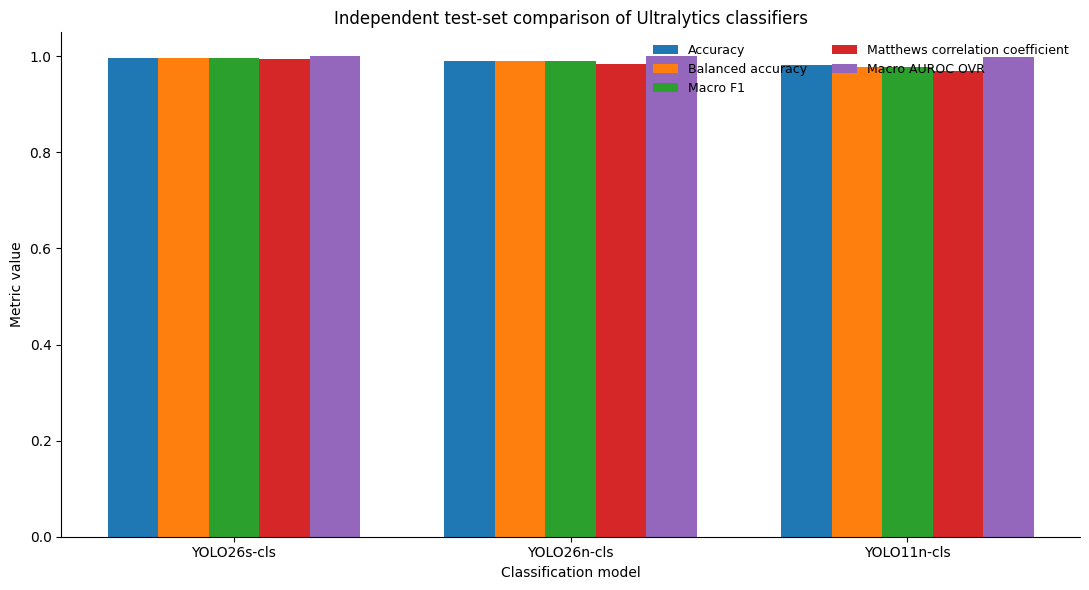

Table 6A. Metrics displayed in the comparative figure


,Model,Accuracy,Balanced_accuracy,Macro_F1,Matthews_correlation_coefficient,Macro_AUROC_OVR
0,YOLO26s-cls,0.9968,0.9960,0.9970,0.9948,1.0000
1,YOLO26n-cls,0.9905,0.9909,0.9905,0.9844,1.0000
2,YOLO11n-cls,0.9810,0.9768,0.9773,0.9687,0.9989


In [40]:
# Cell 29: Comparative performance figure

comparison_metrics = [
    "Accuracy",
    "Balanced_accuracy",
    "Macro_F1",
    "Matthews_correlation_coefficient",
    "Macro_AUROC_OVR"
]

plot_df = model_comparison_df[
    ["Model"] + comparison_metrics
].copy()

x_positions = np.arange(len(plot_df))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(11, 6))

for metric_index, metric_name in enumerate(
    comparison_metrics
):
    offset = (
        metric_index
        - (len(comparison_metrics) - 1) / 2
    ) * bar_width

    ax.bar(
        x_positions + offset,
        plot_df[metric_name],
        width=bar_width,
        label=metric_name.replace("_", " ")
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(
    plot_df["Model"],
    rotation=0
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Metric value")
ax.set_xlabel("Classification model")
ax.set_title(
    "Independent test-set comparison of Ultralytics classifiers"
)
ax.legend(
    frameon=False,
    ncol=2,
    fontsize=9
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

figure_path = FIGURE_DIR / "Figure_7_model_comparison.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

print("Table 6A. Metrics displayed in the comparative figure")
display(plot_df.round(4))

plot_df.to_csv(
    TABLE_DIR / "Table_6A_figure_model_comparison.csv",
    index=False
)

In [41]:
# Cell 30: Select the best model using macro-F1

BEST_MODEL_NAME = model_comparison_df.iloc[0]["Model"]
BEST_MODEL_PATH = Path(
    trained_model_paths[BEST_MODEL_NAME]
)

best_output = test_prediction_outputs[
    BEST_MODEL_NAME
]

best_prediction_df = best_output[
    "predictions"
].copy()

BEST_CLASS_NAMES = best_output["class_names"]

print("Best model:", BEST_MODEL_NAME)
print("Checkpoint:", BEST_MODEL_PATH)
print("Classes   :", BEST_CLASS_NAMES)

Best model: YOLO26s-cls
Checkpoint: /content/rice_stem_borer_research/results/trained_models/YOLO26s-cls/weights/best.pt
Classes   : ['Dead_Heart', 'Healthy', 'White_Head']


In [42]:
# Cell 31: Class-wise precision, recall, and F1

best_classification_report = classification_report(
    best_prediction_df["true_class"],
    best_prediction_df["predicted_class"],
    labels=BEST_CLASS_NAMES,
    target_names=[
        class_name.replace("_", " ")
        for class_name in BEST_CLASS_NAMES
    ],
    output_dict=True,
    zero_division=0
)

best_report_df = (
    pd.DataFrame(best_classification_report)
    .transpose()
    .reset_index()
    .rename(columns={"index": "Class_or_average"})
)

numeric_columns = best_report_df.select_dtypes(
    include=np.number
).columns

best_report_df[numeric_columns] = (
    best_report_df[numeric_columns].round(4)
)

print(
    f"Table 7. Class-wise performance of {BEST_MODEL_NAME}"
)
display(best_report_df)

best_report_df.to_csv(
    TABLE_DIR / "Table_7_best_model_classification_report.csv",
    index=False
)

Table 7. Class-wise performance of YOLO26s-cls


,Class_or_average,precision,recall,f1-score,support
0,Dead Heart,1.0000,1.0000,1.0000,66.0000
1,Healthy,0.9940,1.0000,0.9970,166.0000
2,White Head,1.0000,0.9880,0.9939,83.0000
3,accuracy,0.9968,0.9968,0.9968,0.9968
4,macro avg,0.9980,0.9960,0.9970,315.0000
5,weighted avg,0.9968,0.9968,0.9968,315.0000


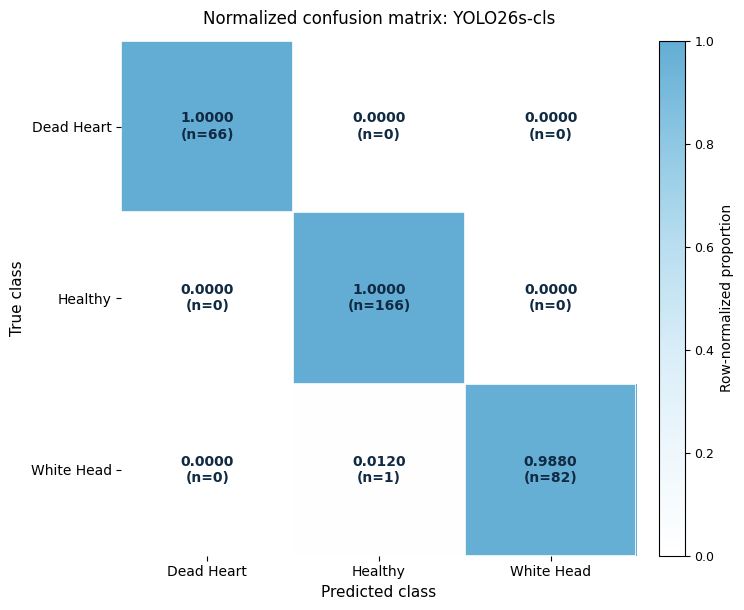

Table 8. Confusion-matrix counts


,Predicted_Dead_Heart,Predicted_Healthy,Predicted_White_Head
True_Dead_Heart,66,0,0
True_Healthy,0,166,0
True_White_Head,0,1,82


In [45]:
# Cell 32: Light-blue confusion matrix with clearly visible values

from matplotlib.colors import LinearSegmentedColormap

confusion_count = confusion_matrix(
    best_prediction_df["true_class"],
    best_prediction_df["predicted_class"],
    labels=BEST_CLASS_NAMES
)

confusion_normalized = confusion_matrix(
    best_prediction_df["true_class"],
    best_prediction_df["predicted_class"],
    labels=BEST_CLASS_NAMES,
    normalize="true"
)

# ---------------------------------------------------------
# Create a light blue publication-friendly colormap
# ---------------------------------------------------------
light_blue_cmap = LinearSegmentedColormap.from_list(
    "light_blue_map",
    [
        "#ffffff",
        "#eef7fc",
        "#d8edf8",
        "#b9deef",
        "#8fc8e4",
        "#63add4"
    ]
)

fig, ax = plt.subplots(figsize=(7.2, 6.2))

image = ax.imshow(
    confusion_normalized,
    interpolation="nearest",
    cmap=light_blue_cmap,
    vmin=0,
    vmax=1
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

colorbar.set_label(
    "Row-normalized proportion",
    fontsize=10
)

colorbar.ax.tick_params(
    labelsize=9
)

tick_labels = [
    class_name.replace("_", " ")
    for class_name in BEST_CLASS_NAMES
]

ax.set_xticks(
    np.arange(len(tick_labels))
)

ax.set_yticks(
    np.arange(len(tick_labels))
)

ax.set_xticklabels(
    tick_labels,
    fontsize=10
)

ax.set_yticklabels(
    tick_labels,
    fontsize=10
)

ax.set_xlabel(
    "Predicted class",
    fontsize=11
)

ax.set_ylabel(
    "True class",
    fontsize=11
)

ax.set_title(
    f"Normalized confusion matrix: {BEST_MODEL_NAME}",
    fontsize=12,
    pad=12
)

# ---------------------------------------------------------
# Add gridlines to separate matrix cells
# ---------------------------------------------------------
ax.set_xticks(
    np.arange(-0.5, len(tick_labels), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(tick_labels), 1),
    minor=True
)

ax.grid(
    which="minor",
    linewidth=1.2,
    color="white"
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# ---------------------------------------------------------
# Add visible normalized values and counts
# ---------------------------------------------------------
for row_index in range(
    confusion_normalized.shape[0]
):
    for column_index in range(
        confusion_normalized.shape[1]
    ):

        normalized_value = confusion_normalized[
            row_index,
            column_index
        ]

        count_value = confusion_count[
            row_index,
            column_index
        ]

        ax.text(
            column_index,
            row_index,
            (
                f"{normalized_value:.4f}\n"
                f"(n={count_value})"
            ),
            ha="center",
            va="center",
            color="#102a43",
            fontsize=10,
            fontweight="bold"
        )

# ---------------------------------------------------------
# Improve figure appearance
# ---------------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "Figure_8_confusion_matrix.png"
)

fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ---------------------------------------------------------
# Underlying count table
# ---------------------------------------------------------
confusion_table = pd.DataFrame(
    confusion_count,
    index=[
        f"True_{class_name}"
        for class_name in BEST_CLASS_NAMES
    ],
    columns=[
        f"Predicted_{class_name}"
        for class_name in BEST_CLASS_NAMES
    ]
)

print(
    "Table 8. Confusion-matrix counts"
)

display(
    confusion_table
)

confusion_table.to_csv(
    TABLE_DIR
    / "Table_8_confusion_matrix_counts.csv"
)

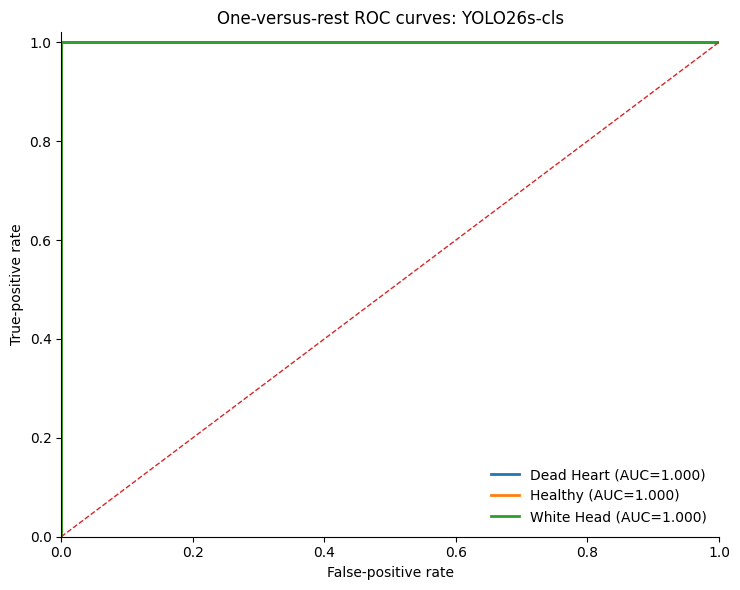

Table 9. Class-specific one-versus-rest AUROC


,Class,AUROC
0,Dead_Heart,1.0
1,Healthy,1.0
2,White_Head,1.0


In [46]:
# Cell 33: Multiclass ROC analysis

class_to_index = {
    class_name: index
    for index, class_name in enumerate(BEST_CLASS_NAMES)
}

y_true_indices = np.array([
    class_to_index[class_name]
    for class_name in best_prediction_df["true_class"]
])

probability_columns = [
    f"prob_{class_name}"
    for class_name in BEST_CLASS_NAMES
]

best_probabilities = best_prediction_df[
    probability_columns
].to_numpy()

y_true_binary = label_binarize(
    y_true_indices,
    classes=np.arange(len(BEST_CLASS_NAMES))
)

roc_table_records = []

fig, ax = plt.subplots(figsize=(7.5, 6))

for class_index, class_name in enumerate(
    BEST_CLASS_NAMES
):
    false_positive_rate, true_positive_rate, thresholds = (
        roc_curve(
            y_true_binary[:, class_index],
            best_probabilities[:, class_index]
        )
    )

    class_auc = auc(
        false_positive_rate,
        true_positive_rate
    )

    ax.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=(
            f"{class_name.replace('_', ' ')} "
            f"(AUC={class_auc:.3f})"
        )
    )

    roc_table_records.append({
        "Class": class_name,
        "AUROC": class_auc
    })

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_title(
    f"One-versus-rest ROC curves: {BEST_MODEL_NAME}"
)
ax.legend(frameon=False, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

figure_path = FIGURE_DIR / "Figure_9_roc_curves.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

roc_summary_df = pd.DataFrame(roc_table_records)
roc_summary_df["AUROC"] = roc_summary_df["AUROC"].round(4)

print("Table 9. Class-specific one-versus-rest AUROC")
display(roc_summary_df)

roc_summary_df.to_csv(
    TABLE_DIR / "Table_9_class_specific_auroc.csv",
    index=False
)

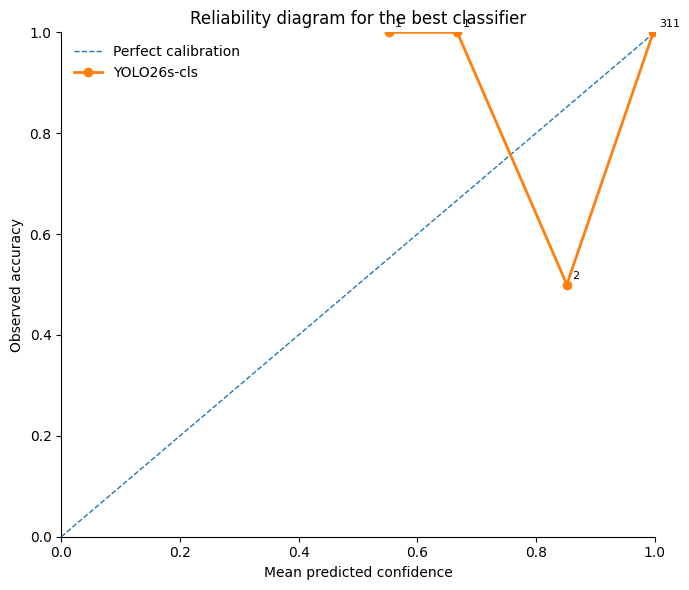

Table 10. Confidence-calibration results


,Bin,Lower_bound,Upper_bound,Number_of_images,Mean_confidence,Observed_accuracy,Absolute_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,1,0.5524,1.0,0.4476
6,7,0.6,0.7,1,0.6674,1.0,0.3326
7,8,0.7,0.8,0,NaN,NaN,NaN
8,9,0.8,0.9,2,0.8521,0.5,0.3521
9,10,0.9,1.0,311,0.9979,1.0,0.0021


In [47]:
# Cell 34: Confidence-calibration analysis

def calibration_table(
    prediction_df,
    number_of_bins=10
):
    confidences = prediction_df[
        "confidence"
    ].to_numpy()

    correctness = (
        prediction_df["true_class"].to_numpy()
        == prediction_df["predicted_class"].to_numpy()
    ).astype(int)

    bin_edges = np.linspace(
        0,
        1,
        number_of_bins + 1
    )

    records = []

    for bin_index in range(number_of_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == number_of_bins - 1:
            mask = (
                (confidences >= lower)
                & (confidences <= upper)
            )
        else:
            mask = (
                (confidences >= lower)
                & (confidences < upper)
            )

        if mask.sum() == 0:
            records.append({
                "Bin": bin_index + 1,
                "Lower_bound": lower,
                "Upper_bound": upper,
                "Number_of_images": 0,
                "Mean_confidence": np.nan,
                "Observed_accuracy": np.nan,
                "Absolute_gap": np.nan
            })
        else:
            mean_confidence = confidences[mask].mean()
            observed_accuracy = correctness[mask].mean()

            records.append({
                "Bin": bin_index + 1,
                "Lower_bound": lower,
                "Upper_bound": upper,
                "Number_of_images": int(mask.sum()),
                "Mean_confidence": mean_confidence,
                "Observed_accuracy": observed_accuracy,
                "Absolute_gap": abs(
                    mean_confidence
                    - observed_accuracy
                )
            })

    return pd.DataFrame(records)

calibration_df = calibration_table(
    best_prediction_df,
    number_of_bins=10
)

valid_calibration_df = calibration_df.dropna(
    subset=["Mean_confidence", "Observed_accuracy"]
)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfect calibration"
)

ax.plot(
    valid_calibration_df["Mean_confidence"],
    valid_calibration_df["Observed_accuracy"],
    marker="o",
    linewidth=2,
    label=BEST_MODEL_NAME
)

for _, row in valid_calibration_df.iterrows():
    ax.annotate(
        str(int(row["Number_of_images"])),
        (
            row["Mean_confidence"],
            row["Observed_accuracy"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted confidence")
ax.set_ylabel("Observed accuracy")
ax.set_title(
    "Reliability diagram for the best classifier"
)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

figure_path = FIGURE_DIR / "Figure_10_calibration_curve.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

calibration_display_df = calibration_df.copy()

numeric_columns = calibration_display_df.select_dtypes(
    include=np.number
).columns

calibration_display_df[numeric_columns] = (
    calibration_display_df[numeric_columns].round(4)
)

print("Table 10. Confidence-calibration results")
display(calibration_display_df)

calibration_display_df.to_csv(
    TABLE_DIR / "Table_10_calibration_results.csv",
    index=False
)

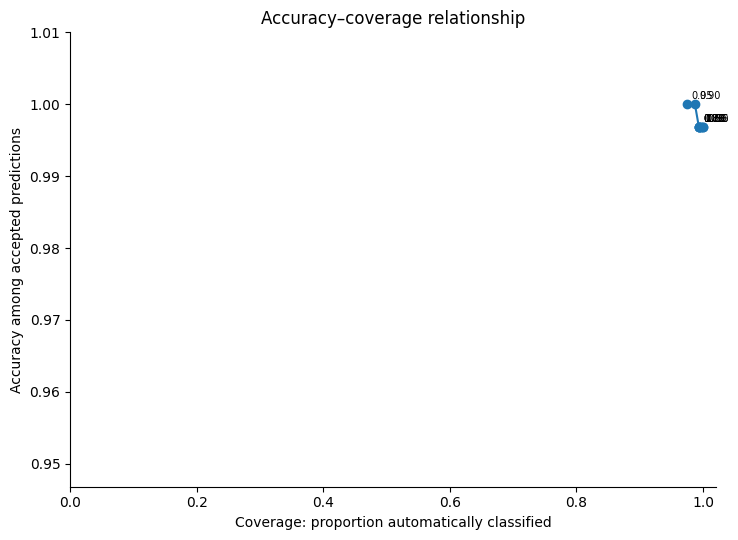

Table 11. Confidence-based selective classification


,Confidence_threshold,Automatically_accepted_images,Referred_images,Coverage,Accepted_accuracy,Selective_risk
0,0.50,315,0,1.0000,0.9968,0.0032
1,0.55,315,0,1.0000,0.9968,0.0032
2,0.60,314,1,0.9968,0.9968,0.0032
3,0.65,314,1,0.9968,0.9968,0.0032
4,0.70,313,2,0.9937,0.9968,0.0032
5,0.75,313,2,0.9937,0.9968,0.0032
6,0.80,313,2,0.9937,0.9968,0.0032
7,0.85,313,2,0.9937,0.9968,0.0032
8,0.90,311,4,0.9873,1.0000,0.0000
9,0.95,307,8,0.9746,1.0000,0.0000


In [48]:
# Cell 35: Selective prediction and expert-referral analysis

confidence_thresholds = np.arange(
    0.50,
    0.96,
    0.05
)

selective_records = []

for threshold in confidence_thresholds:
    accepted_mask = (
        best_prediction_df["confidence"]
        >= threshold
    )

    accepted_count = int(accepted_mask.sum())
    total_count = len(best_prediction_df)

    coverage = accepted_count / total_count

    if accepted_count > 0:
        accepted_accuracy = accuracy_score(
            best_prediction_df.loc[
                accepted_mask,
                "true_class"
            ],
            best_prediction_df.loc[
                accepted_mask,
                "predicted_class"
            ]
        )
    else:
        accepted_accuracy = np.nan

    selective_records.append({
        "Confidence_threshold": threshold,
        "Automatically_accepted_images":
            accepted_count,
        "Referred_images":
            total_count - accepted_count,
        "Coverage": coverage,
        "Accepted_accuracy": accepted_accuracy,
        "Selective_risk": (
            1 - accepted_accuracy
            if not np.isnan(accepted_accuracy)
            else np.nan
        )
    })

selective_prediction_df = pd.DataFrame(
    selective_records
)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.plot(
    selective_prediction_df["Coverage"],
    selective_prediction_df["Accepted_accuracy"],
    marker="o"
)

for _, row in selective_prediction_df.iterrows():
    ax.annotate(
        f"{row['Confidence_threshold']:.2f}",
        (
            row["Coverage"],
            row["Accepted_accuracy"]
        ),
        xytext=(3, 4),
        textcoords="offset points",
        fontsize=7
    )

ax.set_xlabel("Coverage: proportion automatically classified")
ax.set_ylabel("Accuracy among accepted predictions")
ax.set_title("Accuracy–coverage relationship")
ax.set_xlim(0, 1.02)
ax.set_ylim(
    max(
        0,
        selective_prediction_df[
            "Accepted_accuracy"
        ].min() - 0.05
    ),
    1.01
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

figure_path = FIGURE_DIR / "Figure_11_accuracy_coverage.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

selective_display_df = selective_prediction_df.copy()

numeric_columns = selective_display_df.select_dtypes(
    include=np.number
).columns

selective_display_df[numeric_columns] = (
    selective_display_df[numeric_columns].round(4)
)

print("Table 11. Confidence-based selective classification")
display(selective_display_df)

selective_display_df.to_csv(
    TABLE_DIR / "Table_11_selective_prediction.csv",
    index=False
)

In [49]:
# Cell 36: Align model predictions by test image

aligned_correctness = None

for model_name, output in test_prediction_outputs.items():
    current_df = output["predictions"][
        [
            "filename",
            "true_class",
            "predicted_class"
        ]
    ].copy()

    current_df[f"correct_{model_name}"] = (
        current_df["true_class"]
        == current_df["predicted_class"]
    ).astype(int)

    current_df = current_df[
        [
            "filename",
            "true_class",
            f"correct_{model_name}"
        ]
    ]

    if aligned_correctness is None:
        aligned_correctness = current_df
    else:
        aligned_correctness = aligned_correctness.merge(
            current_df,
            on=["filename", "true_class"],
            how="inner"
        )

correctness_columns = [
    column for column in aligned_correctness.columns
    if column.startswith("correct_")
]

print("Aligned test images:", len(aligned_correctness))
display(aligned_correctness.head())

Aligned test images: 315


,filename,true_class,correct_YOLO11n-cls,correct_YOLO26n-cls,correct_YOLO26s-cls
0,02030af46e41_Dead_heart84.jpg,Dead_Heart,1,1,1
1,056bd0989098_Dead_heart331.jpg,Dead_Heart,1,1,1
2,0d7f9d4f5686_Dead_heart320.jpg,Dead_Heart,1,1,1
3,0ea5b6fc3d02_Dead_heart381.jpg,Dead_Heart,0,1,1
4,10a3a57a0c27_Dead_heart403.jpg,Dead_Heart,1,1,1


In [50]:
# Cell 36B: Cochran's Q test implemented directly

from scipy.stats import chi2

def cochran_q_test(binary_matrix):
    """
    Cochran's Q test for k related binary classifiers.
    Rows are test instances and columns are classifiers.
    """
    binary_matrix = np.asarray(
        binary_matrix,
        dtype=float
    )

    n_instances, n_models = binary_matrix.shape

    column_sums = binary_matrix.sum(axis=0)
    row_sums = binary_matrix.sum(axis=1)
    grand_total = binary_matrix.sum()

    numerator = (
        (n_models - 1)
        * (
            n_models * np.sum(column_sums ** 2)
            - grand_total ** 2
        )
    )

    denominator = (
        n_models * grand_total
        - np.sum(row_sums ** 2)
    )

    if denominator == 0:
        return np.nan, np.nan, n_models - 1

    q_statistic = numerator / denominator
    degrees_of_freedom = n_models - 1
    p_value = chi2.sf(
        q_statistic,
        degrees_of_freedom
    )

    return q_statistic, p_value, degrees_of_freedom

q_statistic, q_p_value, q_df = cochran_q_test(
    aligned_correctness[correctness_columns].to_numpy()
)

cochran_q_df = pd.DataFrame([{
    "Test": "Cochran Q",
    "Number_of_models": len(correctness_columns),
    "Number_of_test_images": len(aligned_correctness),
    "Q_statistic": q_statistic,
    "Degrees_of_freedom": q_df,
    "P_value": q_p_value
}])

print("Table 12. Overall paired model-comparison test")
display(cochran_q_df.round(6))

cochran_q_df.to_csv(
    TABLE_DIR / "Table_12_cochran_q_test.csv",
    index=False
)

Table 12. Overall paired model-comparison test


,Test,Number_of_models,Number_of_test_images,Q_statistic,Degrees_of_freedom,P_value
0,Cochran Q,3,315,4.222222,2,0.121103


In [51]:
# Cell 37: Pairwise McNemar tests

from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

pairwise_records = []

for column_a, column_b in combinations(
    correctness_columns,
    2
):
    values_a = aligned_correctness[
        column_a
    ].to_numpy()

    values_b = aligned_correctness[
        column_b
    ].to_numpy()

    contingency_table = np.array([
        [
            np.sum((values_a == 0) & (values_b == 0)),
            np.sum((values_a == 0) & (values_b == 1))
        ],
        [
            np.sum((values_a == 1) & (values_b == 0)),
            np.sum((values_a == 1) & (values_b == 1))
        ]
    ])

    test_result = mcnemar(
        contingency_table,
        exact=True
    )

    pairwise_records.append({
        "Model_A": column_a.replace("correct_", ""),
        "Model_B": column_b.replace("correct_", ""),
        "A_wrong_B_correct":
            contingency_table[0, 1],
        "A_correct_B_wrong":
            contingency_table[1, 0],
        "Raw_P_value": test_result.pvalue
    })

pairwise_mcnemar_df = pd.DataFrame(
    pairwise_records
)

if not pairwise_mcnemar_df.empty:
    rejection, corrected_p, _, _ = multipletests(
        pairwise_mcnemar_df["Raw_P_value"],
        method="holm"
    )

    pairwise_mcnemar_df[
        "Holm_adjusted_P_value"
    ] = corrected_p

    pairwise_mcnemar_df[
        "Significant_at_0.05"
    ] = rejection

print("Table 13. Pairwise exact McNemar tests")
display(pairwise_mcnemar_df.round(6))

pairwise_mcnemar_df.to_csv(
    TABLE_DIR / "Table_13_pairwise_mcnemar.csv",
    index=False
)

Table 13. Pairwise exact McNemar tests


,Model_A,Model_B,A_wrong_B_correct,A_correct_B_wrong,Raw_P_value,Holm_adjusted_P_value,Significant_at_0.05
0,YOLO11n-cls,YOLO26n-cls,6,3,0.507812,1.0000,False
1,YOLO11n-cls,YOLO26s-cls,5,0,0.062500,0.1875,False
2,YOLO26n-cls,YOLO26s-cls,3,1,0.625000,1.0000,False


In [52]:
# Cell 38: Bootstrap confidence intervals for the best model

def bootstrap_metric_ci(
    y_true,
    y_pred,
    metric_function,
    iterations=2000,
    confidence_level=0.95,
    seed=42
):
    random_generator = np.random.default_rng(seed)
    sample_size = len(y_true)
    estimates = []

    for _ in range(iterations):
        indices = random_generator.integers(
            0,
            sample_size,
            size=sample_size
        )

        estimate = metric_function(
            np.asarray(y_true)[indices],
            np.asarray(y_pred)[indices]
        )

        estimates.append(estimate)

    alpha = 1 - confidence_level

    lower = np.quantile(
        estimates,
        alpha / 2
    )

    upper = np.quantile(
        estimates,
        1 - alpha / 2
    )

    point_estimate = metric_function(
        y_true,
        y_pred
    )

    return point_estimate, lower, upper

y_true_best = best_prediction_df[
    "true_class"
].to_numpy()

y_pred_best = best_prediction_df[
    "predicted_class"
].to_numpy()

bootstrap_metric_functions = {
    "Accuracy": accuracy_score,
    "Balanced_accuracy": balanced_accuracy_score,
    "Macro_F1": lambda y_true, y_pred:
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )[2],
    "Matthews_correlation_coefficient":
        matthews_corrcoef
}

bootstrap_records = []

for metric_name, metric_function in (
    bootstrap_metric_functions.items()
):
    estimate, lower, upper = bootstrap_metric_ci(
        y_true_best,
        y_pred_best,
        metric_function,
        iterations=2000,
        confidence_level=0.95,
        seed=SEED
    )

    bootstrap_records.append({
        "Model": BEST_MODEL_NAME,
        "Metric": metric_name,
        "Point_estimate": estimate,
        "CI_95_lower": lower,
        "CI_95_upper": upper
    })

bootstrap_ci_df = pd.DataFrame(
    bootstrap_records
)

print("Table 14. Bootstrap 95% confidence intervals")
display(bootstrap_ci_df.round(4))

bootstrap_ci_df.to_csv(
    TABLE_DIR / "Table_14_bootstrap_confidence_intervals.csv",
    index=False
)

Table 14. Bootstrap 95% confidence intervals


,Model,Metric,Point_estimate,CI_95_lower,CI_95_upper
0,YOLO26s-cls,Accuracy,0.9968,0.9905,1.0
1,YOLO26s-cls,Balanced_accuracy,0.9960,0.9868,1.0
2,YOLO26s-cls,Macro_F1,0.9970,0.9903,1.0
3,YOLO26s-cls,Matthews_correlation_coefficient,0.9948,0.9840,1.0


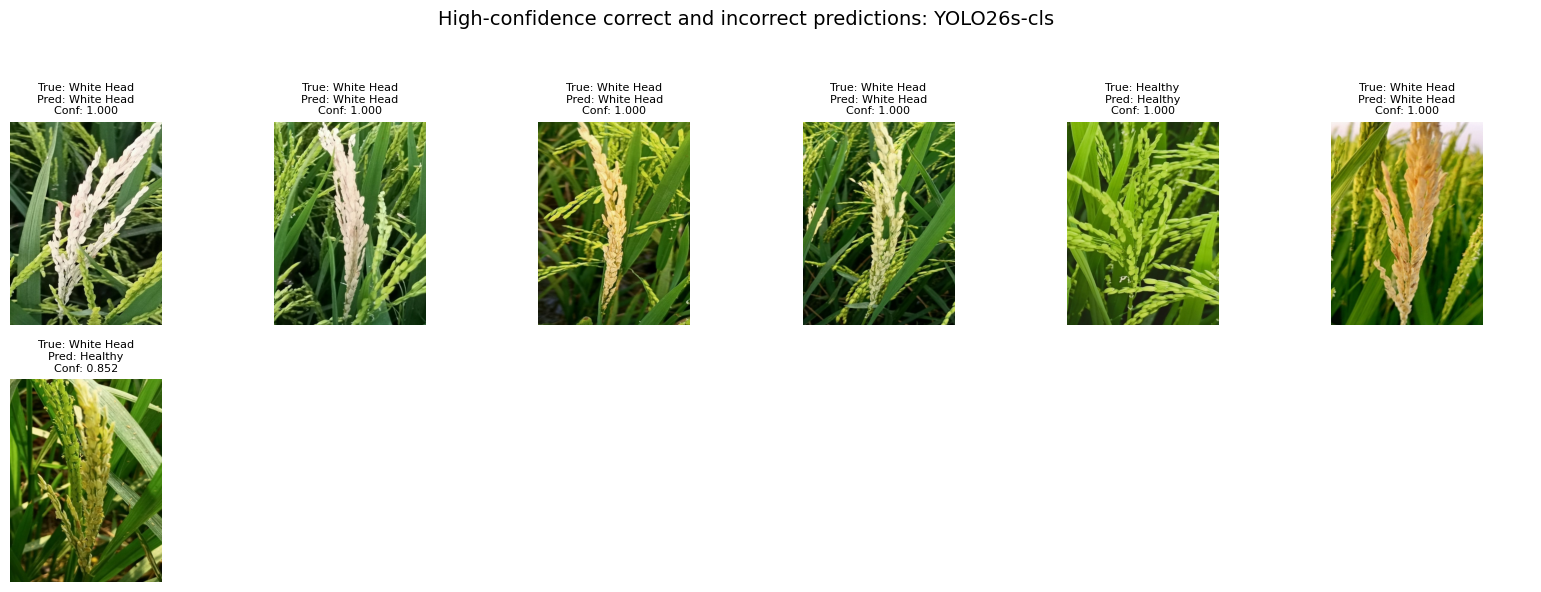

Table 15. Metadata for predictions displayed above


,outcome,filename,true_class,predicted_class,confidence
0,Correct,ef597f3f64f5_WhiteHead296.jpg,White_Head,White_Head,1.0000
1,Correct,e148c3bb79b7_WhiteHead284.jpg,White_Head,White_Head,1.0000
2,Correct,db38a382f396_WhiteHead168.jpg,White_Head,White_Head,1.0000
3,Correct,c3242ab465b7_WhiteHead364.jpg,White_Head,White_Head,1.0000
4,Correct,04e9a2e7a3a6_Healthy (1358).jpg,Healthy,Healthy,1.0000
5,Correct,40006de2caa5_WhiteHead464.jpg,White_Head,White_Head,1.0000
6,Incorrect,323f235af8c3_WhiteHead316.jpg,White_Head,Healthy,0.8517


In [53]:
# Cell 39: Visual error analysis

correct_predictions = best_prediction_df[
    best_prediction_df["true_class"]
    == best_prediction_df["predicted_class"]
].copy()

incorrect_predictions = best_prediction_df[
    best_prediction_df["true_class"]
    != best_prediction_df["predicted_class"]
].copy()

correct_examples = (
    correct_predictions
    .sort_values("confidence", ascending=False)
    .head(6)
)

incorrect_examples = (
    incorrect_predictions
    .sort_values("confidence", ascending=False)
    .head(6)
)

example_df = pd.concat(
    [
        correct_examples.assign(
            outcome="Correct"
        ),
        incorrect_examples.assign(
            outcome="Incorrect"
        )
    ],
    ignore_index=True
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=6,
    figsize=(16, 6)
)

for row_index, outcome in enumerate(
    ["Correct", "Incorrect"]
):
    subset = example_df[
        example_df["outcome"] == outcome
    ].reset_index(drop=True)

    for column_index in range(6):
        ax = axes[row_index, column_index]
        ax.axis("off")

        if column_index >= len(subset):
            continue

        row = subset.iloc[column_index]

        with Image.open(row["filepath"]) as image:
            ax.imshow(image.convert("RGB"))

        ax.set_title(
            (
                f"True: {row['true_class'].replace('_', ' ')}\n"
                f"Pred: {row['predicted_class'].replace('_', ' ')}\n"
                f"Conf: {row['confidence']:.3f}"
            ),
            fontsize=8
        )

        if column_index == 0:
            ax.set_ylabel(
                outcome,
                fontsize=11
            )

fig.suptitle(
    f"High-confidence correct and incorrect predictions: "
    f"{BEST_MODEL_NAME}",
    fontsize=14
)
fig.tight_layout(rect=[0, 0, 1, 0.94])

figure_path = FIGURE_DIR / "Figure_12_prediction_examples.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

example_table = example_df[
    [
        "outcome",
        "filename",
        "true_class",
        "predicted_class",
        "confidence"
    ]
].copy()

example_table["confidence"] = (
    example_table["confidence"].round(4)
)

print("Table 15. Metadata for predictions displayed above")
display(example_table)

example_table.to_csv(
    TABLE_DIR / "Table_15_prediction_examples.csv",
    index=False
)

In [54]:
# Cell 40: Error-pattern analysis

error_summary_df = (
    incorrect_predictions.groupby(
        ["true_class", "predicted_class"]
    )
    .agg(
        Errors=("filename", "count"),
        Mean_confidence=("confidence", "mean"),
        Maximum_confidence=("confidence", "max")
    )
    .reset_index()
    .sort_values("Errors", ascending=False)
)

if error_summary_df.empty:
    print("No incorrect test predictions were observed.")
else:
    error_summary_df[
        ["Mean_confidence", "Maximum_confidence"]
    ] = error_summary_df[
        ["Mean_confidence", "Maximum_confidence"]
    ].round(4)

    print("Table 16. Best-model error patterns")
    display(error_summary_df)

    error_summary_df.to_csv(
        TABLE_DIR / "Table_16_error_patterns.csv",
        index=False
    )

Table 16. Best-model error patterns


,true_class,predicted_class,Errors,Mean_confidence,Maximum_confidence
0,White_Head,Healthy,1,0.8517,0.8517


In [55]:
# Cell 41: Deployment-oriented speed and model-size assessment

speed_records = []

sample_test_images = (
    prepared_manifest_df[
        prepared_manifest_df["split"] == "test"
    ]["prepared_path"]
    .sample(
        n=min(100, len(test_df)),
        random_state=SEED
    )
    .tolist()
)

for model_name, model_path in trained_model_paths.items():
    model = YOLO(model_path)

    # Warm-up
    for warmup_image in sample_test_images[:10]:
        _ = model.predict(
            source=warmup_image,
            imgsz=IMAGE_SIZE,
            device=DEVICE,
            verbose=False
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    for image_path in sample_test_images:
        _ = model.predict(
            source=image_path,
            imgsz=IMAGE_SIZE,
            device=DEVICE,
            verbose=False
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed_seconds = time.perf_counter() - start_time

    model_size_mb = (
        Path(model_path).stat().st_size
        / (1024 ** 2)
    )

    speed_records.append({
        "Model": model_name,
        "Model_size_MB": model_size_mb,
        "Timed_images": len(sample_test_images),
        "Total_time_seconds": elapsed_seconds,
        "Milliseconds_per_image":
            elapsed_seconds
            / len(sample_test_images)
            * 1000,
        "Images_per_second":
            len(sample_test_images)
            / elapsed_seconds,
        "Device": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else "CPU"
        )
    })

speed_comparison_df = pd.DataFrame(
    speed_records
)

numeric_columns = speed_comparison_df.select_dtypes(
    include=np.number
).columns

speed_comparison_df[numeric_columns] = (
    speed_comparison_df[numeric_columns].round(3)
)

print("Table 17. Model size and inference-speed comparison")
display(speed_comparison_df)

speed_comparison_df.to_csv(
    TABLE_DIR / "Table_17_speed_and_model_size.csv",
    index=False
)

Table 17. Model size and inference-speed comparison


,Model,Model_size_MB,Timed_images,Total_time_seconds,Milliseconds_per_image,Images_per_second,Device
0,YOLO11n-cls,3.041,100,1.126,11.262,88.795,Tesla T4
1,YOLO26n-cls,3.041,100,1.132,11.318,88.351,Tesla T4
2,YOLO26s-cls,10.516,100,1.152,11.516,86.833,Tesla T4


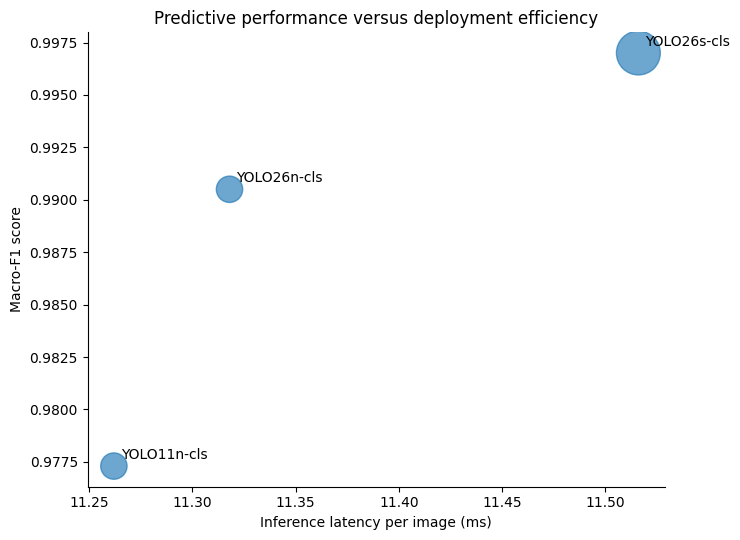

Table 18. Performance-efficiency data


,Model,Macro_F1,Model_size_MB,Milliseconds_per_image,Images_per_second
0,YOLO26s-cls,0.9970,10.516,11.516,86.833
1,YOLO26n-cls,0.9905,3.041,11.318,88.351
2,YOLO11n-cls,0.9773,3.041,11.262,88.795


In [56]:
# Cell 42: Accuracy-efficiency figure

efficiency_df = model_comparison_df[
    ["Model", "Macro_F1"]
].merge(
    speed_comparison_df[
        [
            "Model",
            "Model_size_MB",
            "Milliseconds_per_image",
            "Images_per_second"
        ]
    ],
    on="Model",
    how="inner"
)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

bubble_sizes = (
    efficiency_df["Model_size_MB"]
    / efficiency_df["Model_size_MB"].max()
    * 900
    + 100
)

ax.scatter(
    efficiency_df["Milliseconds_per_image"],
    efficiency_df["Macro_F1"],
    s=bubble_sizes,
    alpha=0.65
)

for _, row in efficiency_df.iterrows():
    ax.annotate(
        row["Model"],
        (
            row["Milliseconds_per_image"],
            row["Macro_F1"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_xlabel("Inference latency per image (ms)")
ax.set_ylabel("Macro-F1 score")
ax.set_title(
    "Predictive performance versus deployment efficiency"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

figure_path = FIGURE_DIR / "Figure_13_accuracy_efficiency.png"
fig.savefig(
    figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

print("Table 18. Performance-efficiency data")
display(efficiency_df.round(4))

efficiency_df.to_csv(
    TABLE_DIR / "Table_18_accuracy_efficiency.csv",
    index=False
)

In [58]:
# Cell 43: Ultralytics validation mode

# Validation batch size is independent of training batch size.
VALIDATION_BATCH_SIZE = 64 if torch.cuda.is_available() else 8

best_model = YOLO(str(BEST_MODEL_PATH))

validation_metrics = best_model.val(
    data=str(PREPARED_DIR),
    split="test",
    imgsz=IMAGE_SIZE,
    batch=VALIDATION_BATCH_SIZE,
    device=DEVICE,
    workers=NUM_WORKERS,
    plots=True,
    verbose=True
)

print("Ultralytics top-1 accuracy:", validation_metrics.top1)
print("Ultralytics top-5 accuracy:", validation_metrics.top5)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-cls summary (fused): 47 layers, 5,437,971 parameters, 0 gradients, 12.1 GFLOPs
train: /content/rice_stem_borer_research/prepared_dataset/train... found 1467 images in 3 classes ✅ 
val: /content/rice_stem_borer_research/prepared_dataset/val... found 314 images in 3 classes ✅ 
test: /content/rice_stem_borer_research/prepared_dataset/test... found 315 images in 3 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1321.0±726.3 MB/s, size: 88.8 KB)
test: Scanning /content/rice_stem_borer_research/prepared_dataset/test... 315 images, 0 corrupt: 100% ━━━━━━━━━━━━ 315/315 2.9Kit/s 0.1s
test: New cache created: /content/rice_stem_borer_research/prepared_dataset/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 1.2s/it 6.0s
                   all      0.997          1
Speed: 1.3ms preprocess, 1.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to 

In [59]:
# Cell 44: Export best model to ONNX

best_model = YOLO(str(BEST_MODEL_PATH))

onnx_export_path = best_model.export(
    format="onnx",
    imgsz=IMAGE_SIZE,
    dynamic=True,
    simplify=True,
    opset=17
)

print("ONNX export:", onnx_export_path)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26s-cls summary (fused): 47 layers, 5,437,971 parameters, 0 gradients, 3.0 GFLOPs

PyTorch: starting from '/content/rice_stem_borer_research/results/trained_models/YOLO26s-cls/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 3) (10.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 583ms
Prepared 4 packages in 3.46s
Installed 4 packages in 528ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.28.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 5.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with 

In [60]:
# Cell 45: Organize exported model

onnx_export_path = Path(onnx_export_path)

final_onnx_path = (
    EXPORT_DIR
    / f"{BEST_MODEL_NAME}_rice_stem_borer.onnx"
)

if onnx_export_path.is_file():
    shutil.copy2(
        onnx_export_path,
        final_onnx_path
    )

    print("Copied ONNX model to:")
    print(final_onnx_path)
else:
    print(
        "The export returned a directory or an unexpected path:",
        onnx_export_path
    )

Copied ONNX model to:
/content/rice_stem_borer_research/results/exports/YOLO26s-cls_rice_stem_borer.onnx


In [61]:
# Cell 46: Benchmark exported model on sample images

benchmark_records = []

benchmark_models = {
    "PyTorch": str(BEST_MODEL_PATH)
}

if final_onnx_path.exists():
    benchmark_models["ONNX"] = str(final_onnx_path)

benchmark_images = sample_test_images[:50]

for format_name, model_path in benchmark_models.items():
    deployment_model = YOLO(model_path)

    # Warm-up
    for image_path in benchmark_images[:5]:
        _ = deployment_model.predict(
            source=image_path,
            imgsz=IMAGE_SIZE,
            device=DEVICE if format_name == "PyTorch" else "cpu",
            verbose=False
        )

    start_time = time.perf_counter()

    for image_path in benchmark_images:
        _ = deployment_model.predict(
            source=image_path,
            imgsz=IMAGE_SIZE,
            device=DEVICE if format_name == "PyTorch" else "cpu",
            verbose=False
        )

    elapsed = time.perf_counter() - start_time

    benchmark_records.append({
        "Format": format_name,
        "Images": len(benchmark_images),
        "Total_seconds": elapsed,
        "Milliseconds_per_image":
            elapsed / len(benchmark_images) * 1000,
        "Images_per_second":
            len(benchmark_images) / elapsed,
        "Device":
            (
                torch.cuda.get_device_name(0)
                if format_name == "PyTorch"
                and torch.cuda.is_available()
                else "CPU"
            )
    })

deployment_benchmark_df = pd.DataFrame(
    benchmark_records
)

numeric_columns = deployment_benchmark_df.select_dtypes(
    include=np.number
).columns

deployment_benchmark_df[numeric_columns] = (
    deployment_benchmark_df[numeric_columns].round(3)
)

print("Table 19. Deployment-format benchmark")
display(deployment_benchmark_df)

deployment_benchmark_df.to_csv(
    TABLE_DIR / "Table_19_deployment_benchmark.csv",
    index=False
)

Loading /content/rice_stem_borer_research/results/exports/YOLO26s-cls_rice_stem_borer.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
Table 19. Deployment-format benchmark


,Format,Images,Total_seconds,Milliseconds_per_image,Images_per_second,Device
0,PyTorch,50,0.592,11.830,84.529,Tesla T4
1,ONNX,50,2.069,41.371,24.171,CPU


In [62]:
# Cell 47: Export publication tables to one Excel workbook

excel_path = RESULTS_DIR / "rice_stem_borer_results_tables.xlsx"

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    count_verification_df.to_excel(
        writer,
        sheet_name="Dataset verification",
        index=False
    )

    class_distribution_table.to_excel(
        writer,
        sheet_name="Class distribution",
        index=False
    )

    split_table_for_display.to_excel(
        writer,
        sheet_name="Data splits",
        index=False
    )

    training_summary_df.to_excel(
        writer,
        sheet_name="Training summary",
        index=False
    )

    model_comparison_df.to_excel(
        writer,
        sheet_name="Model comparison",
        index=False
    )

    best_report_df.to_excel(
        writer,
        sheet_name="Class metrics",
        index=False
    )

    confusion_table.to_excel(
        writer,
        sheet_name="Confusion matrix"
    )

    roc_summary_df.to_excel(
        writer,
        sheet_name="AUROC",
        index=False
    )

    calibration_display_df.to_excel(
        writer,
        sheet_name="Calibration",
        index=False
    )

    selective_display_df.to_excel(
        writer,
        sheet_name="Selective prediction",
        index=False
    )

    bootstrap_ci_df.to_excel(
        writer,
        sheet_name="Bootstrap CI",
        index=False
    )

    speed_comparison_df.to_excel(
        writer,
        sheet_name="Speed and size",
        index=False
    )

    deployment_benchmark_df.to_excel(
        writer,
        sheet_name="Export benchmark",
        index=False
    )

print("Excel workbook saved to:")
print(excel_path)

Excel workbook saved to:
/content/rice_stem_borer_research/results/rice_stem_borer_results_tables.xlsx


In [69]:
# Cell 48: Gradio prediction function and application metadata

import gradio as gr
import numpy as np
import pandas as pd
import torch

# =========================================================
# Developer information
# =========================================================

DEVELOPER_NAME = "Partha Pratim Ray"
DEVELOPER_INSTITUTION = "Sikkim University"
DEVELOPMENT_DATE = "31 July 2026"

# =========================================================
# Dataset information
# =========================================================

DATASET_TITLE = (
    "Symptom-Labeled Image Dataset of Rice Plants "
    "for Stem Borer Infestation Classification"
)

DATASET_CONTRIBUTORS = "Chonchal Khan and Md Assaduzzaman"
DATASET_YEAR = 2025
DATASET_VERSION = "Version 1"
DATASET_DOI = "10.17632/hnfjs42d5g.1"

DATASET_PAGE_URL = (
    "https://data.mendeley.com/datasets/hnfjs42d5g/1"
)

DATASET_CITATION = (
    "Khan, Chonchal; Assaduzzaman, Md (2025), "
    "“Symptom-Labeled Image Dataset of Rice Plants for "
    "Stem Borer Infestation Classification”, "
    "Mendeley Data, V1, doi: 10.17632/hnfjs42d5g.1"
)

# =========================================================
# Model information
# =========================================================

gradio_model = YOLO(str(BEST_MODEL_PATH))

DISPLAY_NAMES = {
    "Healthy": "Healthy",
    "Dead_Heart": "Dead Heart",
    "White_Head": "White Head"
}

SYMPTOM_INFORMATION = {
    "Healthy": (
        "The image shows visual characteristics most consistent "
        "with the healthy class represented in the training dataset."
    ),

    "Dead_Heart": (
        "The image shows visual characteristics most consistent "
        "with the Dead Heart symptom class. Dead Heart is associated "
        "with stem-borer damage during the vegetative growth stage."
    ),

    "White_Head": (
        "The image shows visual characteristics most consistent "
        "with the White Head symptom class. White Head is associated "
        "with stem-borer damage during the reproductive growth stage."
    )
}


def safe_metric_value(
    dataframe,
    model_name,
    metric_name,
    decimal_places=4
):
    """
    Safely obtain a model metric from model_comparison_df.
    """

    try:
        selected_row = dataframe[
            dataframe["Model"] == model_name
        ]

        if selected_row.empty:
            return "Not available"

        value = selected_row.iloc[0][metric_name]

        if pd.isna(value):
            return "Not available"

        return f"{float(value):.{decimal_places}f}"

    except Exception:
        return "Not available"


# ---------------------------------------------------------
# Obtain test metrics when the comparison table exists
# ---------------------------------------------------------

if "model_comparison_df" in globals():

    APP_TEST_ACCURACY = safe_metric_value(
        model_comparison_df,
        BEST_MODEL_NAME,
        "Accuracy"
    )

    APP_BALANCED_ACCURACY = safe_metric_value(
        model_comparison_df,
        BEST_MODEL_NAME,
        "Balanced_accuracy"
    )

    APP_MACRO_F1 = safe_metric_value(
        model_comparison_df,
        BEST_MODEL_NAME,
        "Macro_F1"
    )

    APP_MACRO_AUROC = safe_metric_value(
        model_comparison_df,
        BEST_MODEL_NAME,
        "Macro_AUROC_OVR"
    )

    APP_MCC = safe_metric_value(
        model_comparison_df,
        BEST_MODEL_NAME,
        "Matthews_correlation_coefficient"
    )

else:
    APP_TEST_ACCURACY = "Not available"
    APP_BALANCED_ACCURACY = "Not available"
    APP_MACRO_F1 = "Not available"
    APP_MACRO_AUROC = "Not available"
    APP_MCC = "Not available"


# ---------------------------------------------------------
# Obtain completed training epochs when available
# ---------------------------------------------------------

APP_COMPLETED_EPOCHS = EPOCHS

if "training_summary_df" in globals():

    try:
        selected_training_row = training_summary_df[
            training_summary_df["Model"] == BEST_MODEL_NAME
        ]

        if (
            not selected_training_row.empty
            and "Completed_epochs"
            in selected_training_row.columns
        ):
            completed_value = selected_training_row.iloc[0][
                "Completed_epochs"
            ]

            if not pd.isna(completed_value):
                APP_COMPLETED_EPOCHS = int(completed_value)

    except Exception:
        APP_COMPLETED_EPOCHS = EPOCHS


# =========================================================
# Prediction function
# =========================================================

def classify_rice_symptom(input_image):
    """
    Classify one uploaded rice-plant image into:
    Healthy, Dead Heart, or White Head.
    """

    if input_image is None:
        return (
            {},
            "No image was provided.",
            (
                "Upload a clear RGB image of a rice plant. "
                "The image should show the relevant plant symptoms."
            )
        )

    prediction_results = gradio_model.predict(
        source=input_image,
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        verbose=False
    )

    if not prediction_results:
        return (
            {},
            "Prediction could not be generated.",
            "Please upload another clear rice-plant image."
        )

    result = prediction_results[0]

    if result.probs is None:
        return (
            {},
            "Classification probabilities were not produced.",
            "The uploaded image could not be processed correctly."
        )

    probability_vector = (
        result.probs.data
        .detach()
        .cpu()
        .numpy()
        .astype(float)
    )

    probability_dictionary = {
        DISPLAY_NAMES.get(
            result.names[index],
            result.names[index]
        ): float(probability_vector[index])

        for index in range(
            len(probability_vector)
        )
    }

    predicted_index = int(
        np.argmax(probability_vector)
    )

    predicted_class = result.names[
        predicted_index
    ]

    confidence = float(
        probability_vector[predicted_index]
    )

    readable_class = DISPLAY_NAMES.get(
        predicted_class,
        predicted_class
    )

    symptom_interpretation = SYMPTOM_INFORMATION.get(
        predicted_class,
        (
            "The image was assigned to the predicted class "
            "based on patterns learned from the training dataset."
        )
    )

    # -----------------------------------------------------
    # Confidence-based interpretation
    # -----------------------------------------------------

    if confidence >= 0.85:

        confidence_category = "High confidence"

        referral_message = (
            "The model produced a comparatively confident visual "
            "classification. Field verification is nevertheless "
            "recommended."
        )

    elif confidence >= 0.70:

        confidence_category = "Moderate confidence"

        referral_message = (
            "The model produced a moderately confident result. "
            "The plant should be reviewed carefully, preferably "
            "with confirmation from an agricultural expert."
        )

    else:

        confidence_category = "Low confidence"

        referral_message = (
            "The prediction is uncertain. Expert examination is "
            "recommended because the image may be unclear, may show "
            "overlapping symptoms, or may represent a condition not "
            "included in the three training classes."
        )

    summary = (
        f"Predicted class: {readable_class}\n"
        f"Prediction confidence: {confidence:.4f}\n"
        f"Confidence category: {confidence_category}\n"
        f"Model: {BEST_MODEL_NAME}"
    )

    interpretation = (
        f"{symptom_interpretation}\n\n"
        f"{referral_message}\n\n"
        "Important limitation: This research application classifies "
        "visible image symptoms only. It does not confirm whether the "
        "causal organism is Yellow Stem Borer, Striped Stem Borer, or "
        "another biological or environmental factor. It must not be "
        "used independently for pesticide selection, pesticide dosage, "
        "or other crop-management decisions."
    )

    return (
        probability_dictionary,
        summary,
        interpretation
    )

In [78]:
# Cell 49: Launch the interactive Gradio application

import gradio as gr
import inspect

print("Gradio version:", gr.__version__)


# =========================================================
# Application description
# =========================================================

APP_DESCRIPTION = (
    f"This research prototype classifies uploaded rice-plant images into "
    f"**Healthy**, **Dead Heart**, or **White Head** using the trained "
    f"**{BEST_MODEL_NAME} Ultralytics image-classification model**.\n\n"
    f"Developed by **{DEVELOPER_NAME}, {DEVELOPER_INSTITUTION}**, "
    f"on **{DEVELOPMENT_DATE}**. "
    f"The application is intended for research, demonstration, and "
    f"preliminary visual screening. It is not a substitute for field "
    f"inspection by a qualified agricultural specialist."
)


# =========================================================
# No separate article section required
# =========================================================

APP_ARTICLE = None


# =========================================================
# Version-compatible Gradio configuration
# =========================================================

interface_parameters = inspect.signature(
    gr.Interface.__init__
).parameters

interface_kwargs = {
    "fn": classify_rice_symptom,

    "inputs": gr.Image(
        type="pil",
        label="Upload a rice-plant image"
    ),

    "outputs": [
        gr.Label(
            num_top_classes=3,
            label="Class probabilities"
        ),

        gr.Textbox(
            label="Prediction summary",
            lines=5
        ),

        gr.Textbox(
            label="Interpretation and limitations",
            lines=10
        )
    ],

    "title": "RiceBorer-CLS: Rice Stem-Borer Symptom Classification using YOLO26",

    "description": APP_DESCRIPTION,

    "examples": None,

    "analytics_enabled": False
}

# Add article only when content exists.
if APP_ARTICLE:
    interface_kwargs["article"] = APP_ARTICLE

# Current Gradio versions
if "flagging_mode" in interface_parameters:
    interface_kwargs["flagging_mode"] = "never"

# Older Gradio versions
elif "allow_flagging" in interface_parameters:
    interface_kwargs["allow_flagging"] = "never"


demo = gr.Interface(
    **interface_kwargs
)

demo.launch(
    share=True,
    debug=False,
    show_error=True
)

Gradio version: 6.20.0
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0aecab6cb44c5986b7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [66]:
# Cell 50: Package all research outputs

archive_base = Path(
    "/content/rice_stem_borer_research_outputs"
)

archive_path = shutil.make_archive(
    base_name=str(archive_base),
    format="zip",
    root_dir=str(RESULTS_DIR)
)

print("Output archive created:")
print(archive_path)

Output archive created:
/content/rice_stem_borer_research_outputs.zip


In [67]:
# Cell 51: Download final outputs to the local computer

from google.colab import files

files.download(
    "/content/rice_stem_borer_research_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>